# **GENERATIVE AI PROJECT
### **INSTRUCTOR : DR: TAFSEER AHMED**
# **---------------SUBMITTED BY --------------:**
### **MEMBER 01 (RAO: Muhammad Amaan)**

**DEADLINE OF PROJECT : (24/JUNE /2026)**

# ***OBJECTIVES OF PHASE 02***
### Dataset Loading
### Data Cleaning
### Preprocessing
### Chunking
### Embeddings
### FAISS Database
### Retrieval Testing
### Analysis
### Future Work

In [ ]:
!pip install -q transformers sentence-transformers faiss-cpu \
    torch accelerate bitsandbytes pandas numpy rank-bm25 openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.2 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

PROJECT_PATH = '/content/drive/MyDrive/Colab Notebooks/Tourist_Destinations_new'
os.makedirs(PROJECT_PATH, exist_ok=True)

print('Drive mounted successfully!')
print(f'Project folder: {PROJECT_PATH}')

Mounted at /content/drive
Drive mounted successfully!
Project folder: /content/drive/MyDrive/Colab Notebooks/Tourist_Destinations_new


In [ ]:
from google.colab import files
uploaded = files.upload()  # Upload Tourist_Destinations_new.csv

Saving Pakistan_Tourist_Dataset 2.xlsx to Pakistan_Tourist_Dataset 2.xlsx


In [ ]:
import pandas as pd
import re

# ── Load updated dataset (XLSX with expanded tags) ──────────────────────
df = pd.read_excel('Pakistan_Tourist_Dataset 2.xlsx')

# Clean
df = df.dropna(subset=['title'])
df = df[~df['title'].str.contains('Photo Credit|http|@', case=False, na=False)]
df = df.drop_duplicates(subset=['title'], keep='first')
df = df.reset_index(drop=True)

# Fill NaN fields so no chunk has 'nan' strings
for col in ['category', 'city', 'province', 'description', 'best_season', 'tags', 'text']:
    df[col] = df[col].fillna('').astype(str)

print(f'Loaded {len(df)} destinations')
print(f'Columns: {df.columns.tolist()}')
print(f'\nCategory distribution:')
print(df['category'].value_counts().to_string())
print(f'\nAvg tags per row: {df["tags"].apply(lambda x: len(str(x).split(",")) if x else 0).mean():.1f}')
print(f'\nSample:')
print(df.iloc[0][['title', 'city', 'province', 'best_season']])


Loaded 1442 destinations
Columns: ['title', 'category', 'city', 'province', 'description', 'best_season', 'text', 'tags']

Category distribution:
category
Hotel                       1080
Tourist Attraction           153
Restaurant                    53
Historical Place              44
Food                          32
Recreational Activity         21
Weather                       17
Drink                         12
Sweet                         11
Tour Package (Adventure)      10
Tour Package (Family)          5
Tour Package (Honeymoon)       3
Tour Package (Luxury)          1

Avg tags per row: 35.9

Sample:
title                    Ansoo Lake
city           Naran, Kaghan Valley
province         Khyber Pakhtunkhwa
best_season        Juneâ€“September
Name: 0, dtype: object


## Build Chunks — One per Destination
Each destination becomes one chunk with its full metadata.
No mid-entry splitting — this keeps context intact during retrieval.

In [ ]:
import re

def clean_text(text):
    text = re.sub(r'\s+', ' ', str(text)).strip()
    text = re.sub(r'\[\d+\]', '', text)
    return text

# ═══════════════════════════════════════════════════════════════════════
# STRUCTURED CHUNKING  (Strategy Doc — Section 1 & 2)
# ═══════════════════════════════════════════════════════════════════════
# Each chunk is formatted with explicit entity-type prefixes so embeddings
# learn the field structure, not just bag-of-words semantics.
# Field order is always: CATEGORY → TITLE → CITY → PROVINCE →
#                        DESCRIPTION → TAGS
# This consistency means the embedding for "hotel in Lahore" aligns with
# every chunk that starts with [CATEGORY] Hotel … [CITY] Lahore …
#
# Metadata is stored SEPARATELY in id_to_metadata so FAISS only stores
# the embedding vectors — metadata is looked up by vector id at query time.
# ═══════════════════════════════════════════════════════════════════════

all_chunks   = []   # list of dicts with 'structured_text' + raw fields
id_to_metadata = {}  # vector_id (int) → metadata dict

print('Building structured chunks...')
for i, row in df.iterrows():
    title       = clean_text(row['title'])
    category    = clean_text(row['category'])
    city        = clean_text(row['city'])
    province    = clean_text(row['province'])
    description = clean_text(row['description'])
    tags        = clean_text(row['tags'])
    best_season = clean_text(row['best_season'])

    # ── Structured text for embedding ──────────────────────────────────
    structured_text = (
        f"[CATEGORY] {category}\n"
        f"[TITLE] {title}\n"
        f"[CITY] {city}\n"
        f"[PROVINCE] {province}\n"
        f"[DESCRIPTION] {description}\n"
        f"[TAGS] {tags}"
    )

    # ── Metadata stored separately (not embedded) ────────────────────
    metadata = {
        "id":          i,
        "chunk_id":    f"dest_{i}",
        "type":        category.lower(),
        "category":    category,
        "title":       title,
        "city":        city,
        "province":    province,
        "tags":        [t.strip().lower() for t in tags.split(',') if t.strip()],
        "tags_set":    frozenset(t.strip().lower() for t in tags.split(',') if t.strip()),
        "best_season": best_season,
        "description": description,
    }

    all_chunks.append({
        'text':            structured_text,  # what gets embedded
        'structured_text': structured_text,
        'title':           title,
        'city':            city,
        'province':        province,
        'best_season':     best_season,
        'category':        category,
        'tags':            tags,
        'tags_set':        metadata['tags_set'],
        'id':              f"dest_{i}",
    })
    id_to_metadata[i] = metadata

print(f'Total chunks: {len(all_chunks)}')
print(f'Metadata entries: {len(id_to_metadata)}')
print(f'\nSample structured chunk:')
print(all_chunks[0]['structured_text'])
print(f'\nSample metadata:')
m = id_to_metadata[0]
print(f"  id: {m['id']}, category: {m['category']}, city: {m['city']}")
print(f"  tags (first 5): {m['tags'][:5]}")


Building structured chunks...
Total chunks: 1442
Metadata entries: 1442

Sample structured chunk:
[CATEGORY] Tourist Attraction
[TITLE] Ansoo Lake
[CITY] Naran, Kaghan Valley
[PROVINCE] Khyber Pakhtunkhwa
[DESCRIPTION] Ansoo Lake is situated in Kaghan Valley of Pakistan. It is located near in the Himalayan range at the altitude of 4,245 meters (13,927 ft). This lake is considered to be one of the most beautiful lakes of the world. The name "Ansoo" comes from its tear-like shape. The lake also resembles a human eye with a central ice island resembling the iris and a ridge resembling an eyebrow, which becomes even more prominent when ice melts on the "eyebrow" during the summer. The lake is said to have been discovered in 1993 by Pakistan Air Force pilots who were flying low in the area._x000D_ (Photo Credit: pakfocus.com )
[TAGS] lake, pakistan, tourism, khyber pakhtunkhwa, lakeside, waterbody, scenic lake, freshwater lake, lake view, tourist attraction, sightseeing, nature destination,

## Embeddings — multilingual-e5-large
Same model as the reference notebook. Handles both English and Urdu queries.

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np

print('Loading multilingual-e5-large model...')
embedding_model = SentenceTransformer('intfloat/multilingual-e5-large')
print('Model loaded!')

# ── Embed structured_text ONLY (Strategy Doc — Section 3) ───────────────
# We embed the structured_text field, not the raw description.
# This teaches the model that [CATEGORY] Hotel always means accommodation,
# [TAGS] fort, mughal always means historical architecture, etc.
chunk_texts = [c['structured_text'] for c in all_chunks]

print(f'\nCreating embeddings for {len(chunk_texts)} structured chunks...')
embeddings = embedding_model.encode(
    chunk_texts,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)

print(f'\nEmbeddings shape: {embeddings.shape}')
print(f'Each embedding size: {embeddings.shape[1]} dimensions')


Loading multilingual-e5-large model...


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/160k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

Model loaded!

Creating embeddings for 1442 structured chunks...


Batches:   0%|          | 0/46 [00:00<?, ?it/s]


Embeddings shape: (1442, 1024)
Each embedding size: 1024 dimensions


In [ ]:
import faiss

# ── FAISS stores vectors only (Strategy Doc — Section 3) ────────────────
# Metadata lives in id_to_metadata (built in the chunking cell).
# Vector position i in faiss_index corresponds to id_to_metadata[i].
embedding_dim = embeddings.shape[1]  # 1024 for multilingual-e5-large
faiss_index = faiss.IndexFlatIP(embedding_dim)  # Inner Product = cosine on normalized vecs
faiss_index.add(embeddings.astype(np.float32))

print(f'FAISS index created!')
print(f'Total vectors indexed: {faiss_index.ntotal}')
print(f'Metadata entries: {len(id_to_metadata)}')
print(f'Vector dim: {embedding_dim}')


FAISS index created!
Total vectors indexed: 1442
Metadata entries: 1442
Vector dim: 1024


In [ ]:
import pickle

SAVE_PATH = '/content/drive/MyDrive/Colab Notebooks/Tourist_Destinations_new'

faiss.write_index(faiss_index, f'{SAVE_PATH}/faiss_index.bin')

with open(f'{SAVE_PATH}/chunks_metadata.pkl', 'wb') as f:
    pickle.dump(all_chunks, f)

np.save(f'{SAVE_PATH}/embeddings.npy', embeddings)

print('FAISS index saved!')
print('Chunks metadata saved!')
print('Embeddings saved!')
print(f'\nAll files saved to: {SAVE_PATH}')

FAISS index saved!
Chunks metadata saved!
Embeddings saved!

All files saved to: /content/drive/MyDrive/Colab Notebooks/Tourist_Destinations_new


## Fixing Category Mixing in Retrieval

**Bug:** `retrieve()` searched the entire FAISS index (1,443 chunks across 13 categories) and returned the top-k by raw embedding similarity, with no category constraint. Hotels alone are 1,080/1,443 rows (~75% of the dataset), and many chunks share city/province wording, so a query like *"restaurants in Lahore"* would easily pull back hotels too — they're semantically close (same city words) even though the category is wrong.

**Fix:** a lightweight keyword router (`detect_categories`) detects which category a query is actually asking about (Hotel, Restaurant, Food, Tourist Attraction, Weather, etc.) using word-boundary regex matching — not naive substring checks. This matters: a plain `'eat' in query` would falsely fire on the word "weather" (which contains "eat"), and a generic keyword like "valley" would falsely fire on place names such as "Hunza Valley" no matter what's actually being asked.

When a category is detected, retrieval searches the **full index** (cheap at this dataset size) and filters to that category — this also avoids losing rare categories like Weather (17 rows), Sweet (11), or Drink (12) to pool truncation. When no category is detected (a general query), results are diversified across categories so Hotels can't dominate every general answer. A detected city/province (e.g. "Lahore") is used as a secondary tie-breaker only — it never outranks the correct category, which is what caused a subtler version of this same bug during testing.


## Multilingual Retrieval Pipeline (v5)

This cell upgrades the keyword router and location detector to support **English**, **Urdu-script**, and **Roman Urdu** queries.

### Changes from v4

| Component | v4 | v5 |
|-----------|-------|-------|
| `CATEGORY_KEYWORDS` | English only | + Urdu-script + Roman Urdu per category |
| `LOCATION_TOKENS` | City/province names only | + Urdu + Roman Urdu proximity words |
| `detect_intent` | Matches raw query | Matches raw **and** normalised query |
| `_preprocess_query` | — | Roman-Urdu variant normalisation + char dedup |
| `ROMAN_URDU_NORMALIZATION` | — | 35 canonical forms, 90+ spelling variants |

### Why two-pass matching?
Urdu-script keywords (e.g. `کھانا`) only match the **raw** query.  
Roman-Urdu canonical forms (e.g. `khana`) only match the **normalised** query.  
Running both passes on every keyword ensures neither script is missed.

### Recommended generation model
**`Qwen/Qwen2-1.5B-Instruct`** — strong multilingual (Urdu + English) instruction following.  
Lightweight alternative: `google/mt5-small` for classification/short responses.  
English-focused fallback: `google/gemma-2b-it`.


In [ ]:
import re
import numpy as np
import faiss
from rank_bm25 import BM25Okapi
from collections import defaultdict

# ─────────────────────────────────────────────────
# HYBRID RETRIEVAL PIPELINE  (v5 — Multilingual)
# Strategy Doc Implementation:
#   Section 1: Structured chunking (done in cell 7)
#   Section 2: Metadata stored in id_to_metadata (done in cell 7)
#   Section 3: FAISS over structured_text only (done in cells 9-10)
#   Section 4: Query Understanding  ← this cell   [UPDATED: Urdu + Roman Urdu]
#   Section 5: Metadata Filtering   ← this cell
#   Section 6: Hybrid Retrieval     ← this cell
#              final_score = 0.6 * embedding_score + 0.4 * bm25_score
# ─────────────────────────────────────────────────

# ══════════════════════════════════════════════════════════════════
# 0.  Roman Urdu normalisation
#     Maps common spelling variations to a single canonical form
#     so every variant hits the same keyword bucket.
# ══════════════════════════════════════════════════════════════════
ROMAN_URDU_NORMALIZATION: dict[str, list[str]] = {
    # Food / Restaurant
    "khana":     ["khana", "khanay", "khaana", "khanna", "khane"],
    "zaiqa":     ["zaiqa", "zaika", "zaeqa", "zaiqay", "zaiqe"],
    "biryani":   ["biryani", "biriani", "beryani", "biriyani", "biryane"],
    "karahi":    ["karahi", "karahi", "karrahi", "karhahi"],
    "nihari":    ["nihari", "nehari", "nihhari"],
    "halwa":     ["halwa", "halva", "halwah"],
    "mithai":    ["mithai", "mithaii", "meethai", "mithayi"],
    "jalebi":    ["jalebi", "jaleby", "jalaibi"],
    "barfi":     ["barfi", "burfi", "barfee"],
    "kheer":     ["kheer", "khir", "kheeer"],
    "lassi":     ["lassi", "lassee", "lassey"],
    "chai":      ["chai", "chaye", "chae", "chay", "cha"],
    "qahwa":     ["qahwa", "kahwa", "qehwa", "kehwa"],
    "sharbat":   ["sharbat", "sharbath", "sherbat"],
    # Hotel / Stay
    "rehayish":  ["rehayish", "rehayesh", "rehaish", "rahayish", "rahayesh"],
    "rehna":     ["rehna", "rehnaa", "rehena", "raho"],
    "theharno":  ["theharno", "thahrna", "thehrna", "theharna"],
    "kamra":     ["kamra", "kamrah", "kamar"],
    # Tourist Attraction / Sightseeing
    "ghoomna":   ["ghoomna", "ghummna", "ghoomne", "ghoomein"],
    "dekhna":    ["dekhna", "dekho", "dekhein", "dekhe"],
    "jagah":     ["jagah", "jaga", "jagahen", "jagahein"],
    "maqam":     ["maqam", "mukam", "mokam"],
    "safar":     ["safar", "saffar", "sefer"],
    # Historical
    "qila":      ["qila", "qilah", "qilaa", "kila"],
    "masjid":    ["masjid", "masjed", "masjad"],
    "mazaar":    ["mazaar", "mazar", "mazzar"],
    "dargah":    ["dargah", "dargaa", "dargeh"],
    "taareekh":  ["taareekh", "tarikhi", "tareekhee"],
    "purana":    ["purana", "poorana", "pooraana", "puraana"],
    # Activities
    "hiking":    ["hiking", "haiking", "hykng"],
    "trekking":  ["trekking", "treking", "traking"],
    "rafting":   ["rafting", "rafteng"],
    "skiing":    ["skiing", "skiying", "skying"],
    "safaari":   ["safaari", "safari", "safaree"],
    # Weather
    "mausam":    ["mausam", "mossam", "mausem", "mawsam"],
    "garmi":     ["garmi", "garmee", "garmee"],
    "sardi":     ["sardi", "sardee", "sardiyan"],
    "barish":    ["barish", "baarish", "baarash"],
    "barf":      ["barf", "barff"],
    # Location helpers
    "qareeb":    ["qareeb", "qarib", "qreeb", "kareeb"],
    "nazdeek":   ["nazdeek", "nazdik", "nazdeeq", "nazdick"],
    "paas":      ["paas", "paas", "paaas"],
    "yahan":     ["yahan", "yaan", "yahan"],
    "wahan":     ["wahan", "waan", "udhar"],
    "taleem":    ["taleem", "taaleem", "talim", "taaliim"],
    "doctor":    ["doctor", "docter", "daktar", "daktur"],
    "dawa":      ["dawa", "dawai", "dawaa", "dawaee"],
}

# Build a flat lookup: variant → canonical
_ROMAN_NORM_LOOKUP: dict[str, str] = {}
for canonical, variants in ROMAN_URDU_NORMALIZATION.items():
    for v in variants:
        _ROMAN_NORM_LOOKUP[v] = canonical


def normalize_roman_urdu(text: str) -> str:
    """
    Replace every Roman-Urdu spelling variant with its canonical form.
    Operates on full words (word-boundary regex) to avoid false matches.
    """
    for variant, canonical in _ROMAN_NORM_LOOKUP.items():
        text = re.sub(r'\b' + re.escape(variant) + r'\b', canonical, text, flags=re.IGNORECASE)
    return text


# ══════════════════════════════════════════════════════════════════
# 1.  CATEGORY_KEYWORDS  — English + Urdu-script + Roman Urdu
# ══════════════════════════════════════════════════════════════════
CATEGORY_KEYWORDS: dict[str, list[str]] = {
    'Hotel': [
        # ── English ──────────────────────────────────────
        'hotel', 'hotels', 'stay', 'stays', 'accommodation', 'accommodations',
        'resort', 'resorts', 'guesthouse', 'guest house', 'lodging', 'motel',
        'where to stay', 'place to stay', 'places to stay', 'inn', 'rooms',
        'overnight', 'check in', 'bed and breakfast',
        # ── Urdu script ──────────────────────────────────
        'ہوٹل', 'رہائش', 'قیام', 'رہنا', 'ٹھہرنا', 'کمرہ',
        'قیام گاہ', 'سرائے', 'ریزورٹ',
        # ── Roman Urdu (canonical after normalization) ───
        'rehayish', 'rehna', 'theharno', 'kamra', 'sarae',
        'thehrao', 'kahan thehren', 'kahan rahain',
    ],
    'Restaurant': [
        # ── English ──────────────────────────────────────
        'restaurant', 'restaurants', 'dine', 'dining', 'eatery', 'eateries',
        'cafe', 'cafes', 'where to eat', 'place to eat', 'dine out',
        'food place', 'food outlet', 'local restaurant',
        # ── Urdu script ──────────────────────────────────
        'ریسٹورنٹ', 'کھانے کی جگہ', 'ڈھابہ', 'ہوٹل ریسٹورنٹ',
        'کہاں کھائیں',
        # ── Roman Urdu ───────────────────────────────────
        'dhaba', 'khanay ki jagah', 'kahan khayen', 'kahan khaein',
        'khaney ki jagah',
    ],
    'Food': [
        # ── English ──────────────────────────────────────
        'food', 'dish', 'dishes', 'cuisine', 'delicacy', 'delicacies',
        'recipe', 'recipes', 'eat', 'meal', 'meals', 'local food',
        'traditional food', 'street food', 'must try', 'famous food',
        # ── Urdu script ──────────────────────────────────
        'کھانا', 'خوراک', 'کھانے', 'مشہور کھانا', 'پکوان',
        'مقامی کھانا', 'روایتی کھانا', 'گلی کا کھانا', 'ذائقہ',
        'کیا کھائیں',
        # ── Roman Urdu ───────────────────────────────────
        'khana', 'zaiqa', 'biryani', 'karahi', 'nihari',
        'kya khayen', 'mashoor khana', 'mazedar', 'laziz',
        'khanay', 'pakwan', 'muqami khana',
    ],
    'Drink': [
        # ── English ──────────────────────────────────────
        'drink', 'drinks', 'beverage', 'beverages', 'juice',
        'tea', 'chai', 'lassi', 'sharbat', 'qahwa',
        # ── Urdu script ──────────────────────────────────
        'مشروب', 'مشروبات', 'چائے', 'لسی', 'شربت', 'قہوہ', 'جوس',
        # ── Roman Urdu ───────────────────────────────────
        'chai', 'lassi', 'sharbat', 'qahwa', 'mashroob',
    ],
    'Sweet': [
        # ── English ──────────────────────────────────────
        'sweet', 'sweets', 'dessert', 'desserts', 'mithai',
        'halwa', 'barfi', 'kheer', 'jalebi',
        # ── Urdu script ──────────────────────────────────
        'مٹھائی', 'میٹھا', 'حلوہ', 'برفی', 'جلیبی', 'کھیر', 'مٹھائیاں',
        # ── Roman Urdu ───────────────────────────────────
        'mithai', 'meetha', 'halwa', 'barfi', 'jalebi', 'kheer',
    ],
    'Tourist Attraction': [
        # ── English ──────────────────────────────────────
        'attraction', 'attractions', 'sightseeing', 'places to visit',
        'place to visit', 'things to do', 'tourist spot', 'tourist spots',
        'spots to visit', 'where to go', 'must visit', 'must-visit', 'explore',
        # ── Urdu script ──────────────────────────────────
        'سیر', 'سیاحت', 'دیکھنے کی جگہ', 'گھومنے کی جگہ',
        'سیاحتی مقام', 'بہترین جگہیں', 'کہاں جائیں', 'کہاں گھومیں',
        'مشہور مقامات', 'دیدنی مقامات',
        # ── Roman Urdu ───────────────────────────────────
        'ghoomna', 'dekhna', 'sair', 'siyahat', 'jagah', 'maqam',
        'tourist jagah', 'ghumne ki jagah', 'dekhne ki jagah',
        'kahan jayen', 'mashoor maqamat', 'safar',
    ],
    'Historical Place': [
        # ── English ──────────────────────────────────────
        'historical', 'history', 'heritage', 'fort', 'forts', 'ancient',
        'archaeological', 'ruins', 'monument', 'monuments',
        'mosque', 'shrine', 'mausoleum', 'tomb', 'old city',
        # ── Urdu script ──────────────────────────────────
        'تاریخی', 'تاریخ', 'ورثہ', 'قلعہ', 'قدیم', 'آثار قدیمہ',
        'مسجد', 'مزار', 'درگاہ', 'مقبرہ', 'پرانا', 'تاریخی مقام',
        # ── Roman Urdu ───────────────────────────────────
        'taareekh', 'tarikhi', 'qila', 'masjid', 'mazaar', 'dargah',
        'purana', 'aasaar', 'virasat', 'purani jagah',
    ],
    'Recreational Activity': [
        # ── English ──────────────────────────────────────
        'activity', 'activities', 'adventure', 'adventures', 'hiking',
        'trekking', 'rafting', 'skiing', 'recreational', 'recreation',
        'sports', 'paragliding', 'camping', 'fishing', 'rock climbing',
        'zip line', 'jeep safari', 'mountain biking',
        # ── Urdu script ──────────────────────────────────
        'سرگرمی', 'سرگرمیاں', 'مہم جوئی', 'ہائیکنگ', 'ٹریکنگ',
        'رافٹنگ', 'سکیینگ', 'پیراگلائیڈنگ', 'کیمپنگ', 'ماہی گیری',
        # ── Roman Urdu ───────────────────────────────────
        'hiking', 'trekking', 'rafting', 'skiing', 'safaari',
        'sargarmian', 'maham jooi', 'adventure karein',
        'camping', 'mahi giri',
    ],
    'Weather': [
        # ── English ──────────────────────────────────────
        'weather', 'climate', 'temperature', 'rainfall', 'forecast',
        'snowfall', 'season', 'monsoon', 'humidity',
        # ── Urdu script ──────────────────────────────────
        'موسم', 'موسمی', 'درجہ حرارت', 'بارش', 'برف باری',
        'گرمی', 'سردی', 'موسمی حالات',
        # ── Roman Urdu ───────────────────────────────────
        'mausam', 'garmi', 'sardi', 'barish', 'barf', 'mosam',
        'mausami', 'barfbaari',
    ],
}

TOUR_PACKAGE_CATS = [
    'Tour Package (Adventure)', 'Tour Package (Family)',
    'Tour Package (Honeymoon)', 'Tour Package (Luxury)',
]
TOUR_PACKAGE_SUBKEYWORDS = {
    'Tour Package (Adventure)': [
        'adventure package', 'adventure tour',
        # Urdu
        'مہم جوئی پیکیج', 'ایڈونچر پیکیج',
        # Roman Urdu
        'adventure package', 'maham jooi package',
    ],
    'Tour Package (Family)': [
        'family package', 'family tour',
        # Urdu
        'خاندانی پیکیج', 'فیملی ٹور',
        # Roman Urdu
        'family package', 'khandani safar',
    ],
    'Tour Package (Honeymoon)': [
        'honeymoon package', 'honeymoon tour', 'honeymoon trip',
        # Urdu
        'ہنی مون پیکیج', 'شادی کے بعد سفر',
        # Roman Urdu
        'honeymoon package', 'shadi ke baad safar',
    ],
    'Tour Package (Luxury)': [
        'luxury package', 'luxury tour',
        # Urdu
        'عیاشانہ پیکیج', 'لگژری ٹور',
        # Roman Urdu
        'luxury package', 'aala darje ka safar',
    ],
}


# ══════════════════════════════════════════════════════════════════
# 2.  LOCATION_TOKENS  — extend with Urdu + Roman Urdu proximity words
# ══════════════════════════════════════════════════════════════════
# These are appended AFTER the city/province names are auto-discovered
# from the dataset (done in _build_location_tokens below).
_EXTRA_LOCATION_TOKENS: list[str] = [
    # ── English ──────────────────────────────────────────────────
    'near', 'nearby', 'near me', 'close to', 'around', 'location',
    'in the area of',
    # ── Urdu script ──────────────────────────────────────────────
    'قریب', 'نزدیک', 'جگہ', 'کے قریب', 'کے نزدیک', 'کے پاس', 'یہاں',
    # ── Roman Urdu ───────────────────────────────────────────────
    'qareeb', 'nazdeek', 'jagah', 'ke qareeb', 'ke nazdeek',
    'mere paas', 'yahan', 'iske qareeb', 'pass mein',
]


# Build tag→category lookup from expanded tags (2447+ exclusive tags)
_tag_cat_map = defaultdict(set)
for chunk in all_chunks:
    for tag in chunk['tags_set']:
        _tag_cat_map[tag].add(chunk['category'])

TAG_TO_CATEGORY = {
    t: list(cats)[0]
    for t, cats in _tag_cat_map.items()
    if len(cats) == 1
}
ALL_KNOWN_TAGS = set(_tag_cat_map.keys())

print(f'Query router built:')
print(f'  Keyword categories: {len(CATEGORY_KEYWORDS)}')
print(f'  Exclusive tags for routing: {len(TAG_TO_CATEGORY)}')
print(f'  Total known tags: {len(ALL_KNOWN_TAGS)}')
print(f'  Roman Urdu normalisation variants: {sum(len(v) for v in ROMAN_URDU_NORMALIZATION.values())}')


def _extract_query_tags(query: str) -> set:
    """Find all known tags present in the query (longest match first)."""
    q = query.lower()
    found = set()
    for tag in sorted(ALL_KNOWN_TAGS, key=len, reverse=True):
        if len(tag) >= 3 and tag in q:
            found.add(tag)
    return found


def _preprocess_query(query: str) -> str:
    """
    Multilingual query preprocessing:
    1. Apply Roman-Urdu normalisation (variant → canonical).
    2. Collapse repeated characters (e.g. 'birryaniii' → 'biryani' won't
       fully fix but reduces noise before regex matching).
    Urdu-script text is left unchanged — regex matching handles it as-is.
    """
    q = normalize_roman_urdu(query)
    # Collapse 3+ repeated characters → 2 (e.g. "khaanaa" → "khaana")
    q = re.sub(r'(.)\1{2,}', r'\1\1', q)
    return q


def detect_intent(query: str) -> dict:
    """
    Strategy Doc — Section 4: Query Understanding (Multilingual v5)
    Supports English, Urdu-script, and Roman Urdu.

    Returns:
        categories : set of matched dataset categories
        locations  : set of city/province strings detected
        query_tags : set of known tags found in query
        filters    : metadata filter dict for Section 5
    """
    # ── Preprocess for Roman-Urdu normalisation ────────────────
    q_raw  = query.lower()           # original (keeps Urdu script)
    q_norm = _preprocess_query(query).lower()   # normalized (Roman Urdu canonical)

    # ── 1. Keyword phrases (highest priority) ──────────────────
    # Match against BOTH raw and normalised query so that
    #   (a) Urdu-script keywords hit the raw query
    #   (b) Roman-Urdu canonical keywords hit the normalised query
    categories = set()
    for cat, keywords in CATEGORY_KEYWORDS.items():
        for kw in keywords:
            pattern = r'\b' + re.escape(kw) + r'\b'
            if re.search(pattern, q_raw) or re.search(pattern, q_norm):
                categories.add(cat)
                break

    specific_pkg = False
    for cat, kws in TOUR_PACKAGE_SUBKEYWORDS.items():
        for kw in kws:
            pattern = r'\b' + re.escape(kw) + r'\b'
            if re.search(pattern, q_raw) or re.search(pattern, q_norm):
                categories.add(cat)
                specific_pkg = True
    if not specific_pkg and re.search(
            r'\b(tour package|tour packages|package|packages|itinerary|پیکیج|ٹور)\b',
            q_raw + ' ' + q_norm):
        categories.update(TOUR_PACKAGE_CATS)

    # ── 2. Tag signals — only when keyword router found nothing ─
    query_tags = _extract_query_tags(q_raw) | _extract_query_tags(q_norm)
    if not categories:
        for tag in query_tags:
            cat = TAG_TO_CATEGORY.get(tag)
            if cat:
                categories.add(cat)

    # ── 3. Location detection ───────────────────────────────────
    locations = set()
    for tok in sorted(LOCATION_TOKENS, key=len, reverse=True):
        tl = tok.lower()
        if len(tl) >= 4 and (tl in q_raw or tl in q_norm):
            locations.add(tl)

    # ── 4. Build metadata filter dict ──────────────────────────
    filters = {}
    if categories:
        filters['category'] = categories
    if locations:
        filters['location'] = locations

    return {
        'categories': categories,
        'locations':  locations,
        'query_tags': query_tags,
        'filters':    filters,
    }


# ── Location token index ───────────────────────────────────────
def _build_location_tokens(chunks):
    tokens = set()
    for c in chunks:
        for field in ('city', 'province'):
            val = str(c.get(field, '') or '')
            if not val or val.lower() == 'nan':
                continue
            tokens.add(val.strip())
            for part in val.split(','):
                p = part.strip()
                if len(p) >= 4:
                    tokens.add(p)
    # Add multilingual proximity / direction words
    tokens.update(_EXTRA_LOCATION_TOKENS)
    return sorted(tokens, key=len, reverse=True)

LOCATION_TOKENS = _build_location_tokens(all_chunks)
print(f'  Location tokens (incl. multilingual extras): {len(LOCATION_TOKENS)}')


# ── Section 5: Metadata Filtering ─────────────────────────────
def apply_metadata_filter(candidate_ids: list, filters: dict) -> list:
    """
    Filter vector search results by metadata BEFORE scoring.
    Prevents restaurants appearing for attraction queries, hotels for
    food queries, etc. Returns only ids that pass all filters.
    """
    if not filters:
        return candidate_ids

    passed = []
    for vid in candidate_ids:
        meta = id_to_metadata.get(vid)
        if not meta:
            continue

        # Category filter
        if 'category' in filters:
            if meta['category'] not in filters['category']:
                continue

        # Location filter (soft — passes if NO location specified)
        if 'location' in filters and filters['location']:
            city = meta['city'].lower()
            prov = meta['province'].lower()
            if not any(loc in city or loc in prov for loc in filters['location']):
                continue

        passed.append(vid)
    return passed


# ── BM25 index ────────────────────────────────────────────────
def _tokenize(text: str) -> list:
    """
    Tokenise for BM25. Keeps:
    - ASCII alphanumerics (English + Roman Urdu)
    - Urdu Unicode block U+0600–U+06FF
    """
    return re.sub(r'[^a-z0-9\u0600-\u06ff ]', ' ', text.lower()).split()

def build_bm25(chunks):
    corpus = [_tokenize(c['structured_text']) for c in chunks]
    return BM25Okapi(corpus)

bm25_index = build_bm25(all_chunks)
print(f'BM25 index built over {len(all_chunks)} structured chunks')


# ── Per-category FAISS indices ────────────────────────────────
def build_model_specific_category_indices(chunks, emb_matrix):
    """Builds per-category FAISS indices and centroids for a given embedding matrix."""
    buckets = defaultdict(list)
    for idx, (chunk, emb) in enumerate(zip(chunks, emb_matrix)):
        buckets[chunk['category']].append((chunk, emb, idx))

    cat_faiss, cat_chunk_list_local, centroids = {}, {}, {}
    for cat, items in buckets.items():
        vecs = np.array([e for _, e, _ in items], dtype=np.float32)
        if vecs.shape[0] == 0:
            continue
        idx_faiss  = faiss.IndexFlatIP(vecs.shape[1])
        idx_faiss.add(vecs)
        cat_faiss[cat]           = idx_faiss
        cat_chunk_list_local[cat] = [(c, global_idx) for c, _, global_idx in items]
        c = vecs.mean(axis=0)
        centroids[cat] = c / (np.linalg.norm(c) + 1e-9)

    cent_cats   = list(cat_faiss.keys())
    cent_matrix = np.stack([centroids[c] for c in cent_cats]).astype(np.float32)

    # Auto-calibrate semantic fallback threshold
    self_sims = []
    for c_item, emb in zip(chunks, emb_matrix):
        cat = c_item['category']
        if cat in centroids:
            self_sims.append(float(np.dot(emb, centroids[cat])))
    min_sim = float(np.percentile(self_sims, 20)) if self_sims else 0.0

    print(f'Built {len(cat_faiss)} per-category FAISS indices')
    print(f'  Auto-calibrated semantic min_similarity = {min_sim:.4f}')
    return cat_faiss, cat_chunk_list_local, cent_matrix, cent_cats, min_sim

# Build base category indices for the default embedding model
cat_faiss_base, cat_chunk_list_base, cent_matrix_base, cent_cats_base, min_sim_base = \
    build_model_specific_category_indices(all_chunks, embeddings.astype(np.float32))

def _semantic_fallback(qvec, cent_matrix_instance, cent_cats_instance, min_sim_instance):
    sims  = cent_matrix_instance @ qvec
    order = np.argsort(-sims)
    top1  = float(sims[order[0]])
    top2  = float(sims[order[1]]) if len(order) > 1 else -1.0
    if top1 >= min_sim_instance and (top1 - top2) >= 0.01:
        return {cent_cats_instance[order[0]]}
    return set()


# ── Section 6: Hybrid Retrieval ───────────────────────────────
# final_score = 0.6 * embedding_score + 0.4 * bm25_score
FAISS_WEIGHT = 0.6
BM25_WEIGHT  = 0.4


def hybrid_score(faiss_sim: float, bm25_norm: float) -> float:
    """Weighted combination per strategy doc."""
    return FAISS_WEIGHT * faiss_sim + BM25_WEIGHT * bm25_norm


def _get_bm25_scores(query_tokens: list, chunk_subset_ids: list) -> dict:
    """BM25 scores for a subset of chunk indices, normalised to [0,1]."""
    if not query_tokens:
        return {}
    all_scores = bm25_index.get_scores(query_tokens)
    subset_scores = {i: float(all_scores[i]) for i in chunk_subset_ids}
    max_s = max(subset_scores.values()) if subset_scores else 1.0
    if max_s == 0:
        return {i: 0.0 for i in chunk_subset_ids}
    return {i: s / max_s for i, s in subset_scores.items()}


Query router built:
  Keyword categories: 9
  Exclusive tags for routing: 2447
  Total known tags: 3163
  Roman Urdu normalisation variants: 165
  Location tokens (incl. multilingual extras): 398
BM25 index built over 1442 structured chunks
Built 13 per-category FAISS indices
  Auto-calibrated semantic min_similarity = 0.9216


In [ ]:
# ── Main retrieval function ─────────────────────────
def category_aware_search(query: str,
                           embedding_model_instance,
                           faiss_index_instance,
                           cat_faiss_instance,
                           cat_chunk_list_instance, # Added this parameter
                           cent_matrix_instance,
                           cent_cats_instance,
                           min_sim_instance,
                           all_chunks_instance,
                           embeddings_instance, # Pass the full embeddings matrix for MMR re-ranking
                           top_k: int = 5,
                           use_mmr: bool = True,
                           mmr_lambda: float = 0.7) -> list:
    """
    Full pipeline implementing all 6 sections of the strategy doc:

    1. Encode query using the same model that built the embeddings
    2. Detect intent (categories + locations + tags)  → Section 4
    3. Metadata filter                                → Section 5
    4a. Category known → per-category FAISS + BM25 hybrid  → Section 6
    4b. No category   → full index with diversity cap
    5. Hybrid score: 0.6 × FAISS + 0.4 × BM25        → Section 6
    6. MMR re-ranking for variety
    """
    qvec = embedding_model_instance.encode(
        [query], normalize_embeddings=True
    ).astype(np.float32)[0]

    intent       = detect_intent(query)
    categories   = intent['categories']
    query_tags   = intent['query_tags']
    query_tokens = _tokenize(query)
    filters      = intent['filters']

    # Semantic centroid fallback when keyword/tag routing found nothing
    if not categories:
        categories = _semantic_fallback(qvec, cent_matrix_instance, cent_cats_instance, min_sim_instance)

    # ── 4a: Category-scoped hybrid search ──────────────────
    if categories:
        faiss_hits = {}  # global_id → (faiss_score, chunk, global_id)
        total_cat_docs = sum(cat_faiss_instance[c].ntotal for c in categories if c in cat_faiss_instance)
        pool_size = min(max(top_k * 8, 40), total_cat_docs)

        for cat in categories:
            if cat not in cat_faiss_instance:
                continue
            # Adjust k for individual category search to get enough candidates for the pool_size
            k_cat = min(pool_size, cat_faiss_instance[cat].ntotal)
            if k_cat == 0: # Handle empty category
                continue
            scores, indices = cat_faiss_instance[cat].search(qvec.reshape(1, -1), k_cat)
            for fscore, local_idx in zip(scores[0], indices[0]):
                if local_idx == -1:
                    continue
                # cat_chunk_list_local stores (chunk, global_idx)
                chunk, global_id = cat_chunk_list_instance[cat][local_idx]
                faiss_hits[global_id] = (float(fscore), chunk, global_id)

        # Apply metadata filter (Section 5)
        filtered_ids = apply_metadata_filter(list(faiss_hits.keys()), filters)
        if not filtered_ids:
            # If filtering is too restrictive, relax it by using all faiss_hits (might bring back mixing)
            # Or, for more robustness, ensure a minimum number of candidates from each selected category.
            filtered_ids = list(faiss_hits.keys())

        # BM25 scores for filtered candidates
        bm25_scores = _get_bm25_scores(query_tokens, filtered_ids)

        # Hybrid scoring
        candidates = []
        for vid in filtered_ids:
            fscore = faiss_hits[vid][0]
            bscore = bm25_scores.get(vid, 0.0)
            final  = hybrid_score(fscore, bscore)
            candidates.append((final, faiss_hits[vid][1], vid)) # (score, chunk, global_id)

    # ── 4b: Full index with diversity cap ─────────────
    else:
        pool = min(len(all_chunks_instance), max(top_k * 10, 80))
        scores, indices = faiss_index_instance.search(qvec.reshape(1, -1), pool)
        faiss_hits = {int(i): (float(s), all_chunks_instance[int(i)], int(i))
                      for s, i in zip(scores[0], indices[0]) if i != -1}

        bm25_scores = _get_bm25_scores(query_tokens, list(faiss_hits.keys()))

        merged = []
        for vid, (fscore, chunk, _) in faiss_hits.items():
            bscore = bm25_scores.get(vid, 0.0)
            merged.append((hybrid_score(fscore, bscore), chunk, vid))

        # Diversity cap: no category takes more than top_k//3+1 slots
        max_per_cat = max(1, top_k // 3 + 1)
        merged.sort(key=lambda x: -x[0])
        counts, candidates, leftover = {}, [], []
        for item in merged:
            cat = item[1]['category']
            if counts.get(cat, 0) < max_per_cat:
                candidates.append(item)
                counts[cat] = counts.get(cat, 0) + 1
            else:
                leftover.append(item)
            if len(candidates) >= top_k * 3:
                break
        candidates = candidates + leftover

    # Sort by hybrid score, tag overlap as tiebreaker
    candidates.sort(key=lambda x: (
        -len(x[1].get('tags_set', frozenset()) & query_tags),
        -x[0]
    ))

    # MMR re-ranking
    if use_mmr and len(candidates) > top_k:
        candidates = _mmr_rerank(candidates, qvec, embeddings_instance, top_k, lam=mmr_lambda)
    else:
        candidates = candidates[:top_k]

    # Build results
    results = []
    for final_score, chunk, vid in candidates:
        meta = id_to_metadata.get(vid, {}) # Use global id_to_metadata as it's static
        results.append({
            'text':        chunk['structured_text'],
            'title':       chunk['title'],
            'city':        chunk['city'],
            'province':    chunk['province'],
            'category':    chunk['category'],
            'best_season': chunk['best_season'],
            'tags':        chunk.get('tags', ''),
            'metadata':    meta,
            'score':       round(final_score, 6),
            'intent':      intent,
        })
    return results
def _mmr_rerank(candidates: list, qvec: np.ndarray,
                emb_matrix: np.ndarray, top_k: int, lam: float = 0.7) -> list:
    """
    Maximal Marginal Relevance.
    score = ̵ ̣ × sim(result, query) − (1−̵ ̣) × max_sim(result, already_selected)
    ̵ ̣=0.7 keeps relevance dominant while preventing near-duplicate results
    (e.g. 5 variants of the same hotel chain for "hotels in Lahore").
    """
    if len(candidates) <= top_k:
        return candidates

    selected, remaining = [], list(candidates)
    while len(selected) < top_k and remaining:
        best_score, best_idx = -1e9, 0
        for i, (score, chunk, vid) in enumerate(remaining):
            qsim = float(emb_matrix[vid] @ qvec)
            red  = (max(float(emb_matrix[vid] @ emb_matrix[s[2]])
                        for s in selected)
                    if selected else 0.0)
            mmr = lam * qsim - (1 - lam) * red
            if mmr > best_score:
                best_score, best_idx = mmr, i
        selected.append(remaining.pop(best_idx))
    return selected

In [ ]:

def retrieve(query, top_k=5, use_mmr=True):
    return category_aware_search(
        query, embedding_model, faiss_index, # Base model, base faiss index
        cat_faiss_base, cat_chunk_list_base, cent_matrix_base, cent_cats_base, min_sim_base, # Base category indices and centroids
        all_chunks, embeddings, # Base all_chunks and embeddings for MMR
        top_k=top_k, use_mmr=use_mmr, mmr_lambda=0.7
    )

# ── Retrieval Tests ─────────────────────────
print('=' * 55)
print('TEST 1 — English Query (Tourist Attraction)')
print('=' * 55)
for r in retrieve('Best places to visit in Swat', top_k=3):
    print(f"  [{r['score']:.4f}] {r['title']} | {r['category']} | {r['city']}")

print()
print('=' * 55)
print('TEST 2 — Urdu Query (Historical Place)')
print('=' * 55)
for r in retrieve('پاکستان میں تاریخی قلعے', top_k=3):
    print(f"  [{r['score']:.4f}] {r['title']} | {r['category']} | {r['city']}")

print()
print('=' * 55)
print('TEST 3 — Category Mixing Regression')
print('=' * 55)
for q in [
    'Top restaurants in Lahore',
    'Best hotels in Murree',
    'What food should I try in Peshawar?',
    'where can I get good biryani',
    'Historical forts in Punjab',
]:
    res  = retrieve(q, top_k=5)
    cats = set(r['category'] for r in res)
    status = 'PASS' if len(cats) == 1 else 'WARNING — mixed'
    print(f"  [{status}] '{q}' → {cats}")

print()
print('=' * 55)
print('TEST 4 — Intent Detection')
print('=' * 55)
for q in [
    'Historical places in Lahore',
    'Best biryani in Karachi',
    'Hotels in Murree',
    'Things to do in Hunza',
]:
    res = retrieve(q, top_k=1)
    intent = res[0]['intent'] if res else {}
    print(f"  '{q}'")
    print(f"    → Detected categories: {intent.get('categories', set())}")
    print(f"    → Detected locations:  {intent.get('locations', set())}")
    print(f"    → Query tags:          {list(intent.get('query_tags', set()))[:5]}")
    print()

TEST 1 — English Query (Tourist Attraction)
  [0.8513] Fizagat Park | Tourist Attraction | Mingora, Swat Valley
  [0.8099] Matiltan | Tourist Attraction | Kalam, Swat Valley
  [0.7873] Bahrain Town | Tourist Attraction | Bahrain, Swat Valley

TEST 2 — Urdu Query (Historical Place)
  [0.4819] Lahore Fort | Historical Place | Lahore, Walled City
  [0.4748] Sethi House | Historical Place | Peshawar, Walled City
  [0.4700] Faisal Mosque | Historical Place | Islamabad, Capital Territory

TEST 3 — Category Mixing Regression
  [PASS] 'Top restaurants in Lahore' → {'Restaurant'}
  [PASS] 'Best hotels in Murree' → {'Hotel'}
  [PASS] 'What food should I try in Peshawar?' → {'Food'}
  [PASS] 'where can I get good biryani' → {'Food'}
  [PASS] 'Historical forts in Punjab' → {'Historical Place'}

TEST 4 — Intent Detection
  'Historical places in Lahore'
    → Detected categories: {'Historical Place'}
    → Detected locations:  {'lahore'}
    → Query tags:          ['lahore', 'historical']

  'Best b

## Retrieval Model Comparison

In [ ]:
import faiss

# Load additional embedding models
print('Loading paraphrase-multilingual-MiniLM-L12-v2 model...')
embedding_model_minilm = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')
print('paraphrase-multilingual-MiniLM-L12-v2 Model loaded!')

print('Loading bge-small-en-v1.5 model...')
embedding_model_bge = SentenceTransformer('BAAI/bge-small-en-v1.5')
print('bge-small-en-v1.5 Model loaded!')

print('Loading multilingual-e5-small model...')
embedding_model_e5_small = SentenceTransformer('intfloat/multilingual-e5-small')
print('multilingual-e5-small Model loaded!')

# Generate embeddings for each new model
print(f'\nCreating embeddings for paraphrase-multilingual-MiniLM-L12-v2...')
embeddings_minilm = embedding_model_minilm.encode(
    chunk_texts,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)
print(f'Embeddings shape (MiniLM): {embeddings_minilm.shape}')

print(f'\nCreating embeddings for bge-small-en-v1.5...')
embeddings_bge = embedding_model_bge.encode(
    chunk_texts,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)
print(f'Embeddings shape (BGE): {embeddings_bge.shape}')

print(f'\nCreating embeddings for multilingual-e5-small...')
embeddings_e5_small = embedding_model_e5_small.encode(
    chunk_texts,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)
print(f'Embeddings shape (e5-small): {embeddings_e5_small.shape}')

# Create FAISS indexes for each new model
embedding_dim_minilm = embeddings_minilm.shape[1]
faiss_index_minilm = faiss.IndexFlatIP(embedding_dim_minilm)
faiss_index_minilm.add(embeddings_minilm.astype(np.float32))
print(f'\nFAISS index created for paraphrase-multilingual-MiniLM-L12-v2! Total vectors indexed: {faiss_index_minilm.ntotal}')

embedding_dim_bge = embeddings_bge.shape[1]
faiss_index_bge = faiss.IndexFlatIP(embedding_dim_bge)
faiss_index_bge.add(embeddings_bge.astype(np.float32))
print(f'FAISS index created for bge-small-en-v1.5! Total vectors indexed: {faiss_index_bge.ntotal}')

embedding_dim_e5_small = embeddings_e5_small.shape[1]
faiss_index_e5_small = faiss.IndexFlatIP(embedding_dim_e5_small)
faiss_index_e5_small.add(embeddings_e5_small.astype(np.float32))
print(f'FAISS index created for multilingual-e5-small! Total vectors indexed: {faiss_index_e5_small.ntotal}')

# Build model-specific category indices and centroids
print('\nBuilding model-specific category indices for MiniLM...')
cat_faiss_minilm, cat_chunk_list_minilm, cent_matrix_minilm, cent_cats_minilm, min_sim_minilm = \
    build_model_specific_category_indices(all_chunks, embeddings_minilm.astype(np.float32))

print('\nBuilding model-specific category indices for BGE...')
cat_faiss_bge, cat_chunk_list_bge, cent_matrix_bge, cent_cats_bge, min_sim_bge = \
    build_model_specific_category_indices(all_chunks, embeddings_bge.astype(np.float32))

print('\nBuilding model-specific category indices for e5-small...')
cat_faiss_e5_small, cat_chunk_list_e5_small, cent_matrix_e5_small, cent_cats_e5_small, min_sim_e5_small = \
    build_model_specific_category_indices(all_chunks, embeddings_e5_small.astype(np.float32))


# Retrieval function that can use any model and index - now routed through the
# same category-aware search used by retrieve(), so every compared embedding
# model benefits from the category-mixing fix too (instead of duplicating the
# old unfiltered top-k logic, which had the same mixing bug as retrieve() did).
def custom_retrieve(query, embedding_model_instance, faiss_index_instance,
                      cat_faiss_instance, cat_chunk_list_instance, cent_matrix_instance,
                      cent_cats_instance, min_sim_instance, embeddings_instance, top_k=5):
    return category_aware_search(query, embedding_model_instance, faiss_index_instance,
                                 cat_faiss_instance, cat_chunk_list_instance, cent_matrix_instance,
                                 cent_cats_instance, min_sim_instance,
                                 all_chunks, embeddings_instance, top_k=top_k)


Loading paraphrase-multilingual-MiniLM-L12-v2 model...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Embeddings shape (MiniLM): (1442, 384)

Creating embeddings for bge-small-en-v1.5...


Batches:   0%|          | 0/46 [00:00<?, ?it/s]

Embeddings shape (BGE): (1442, 384)

Creating embeddings for multilingual-e5-small...


Batches:   0%|          | 0/46 [00:00<?, ?it/s]

Embeddings shape (e5-small): (1442, 384)

FAISS index created for paraphrase-multilingual-MiniLM-L12-v2! Total vectors indexed: 1442
FAISS index created for bge-small-en-v1.5! Total vectors indexed: 1442
FAISS index created for multilingual-e5-small! Total vectors indexed: 1442

Building model-specific category indices for MiniLM...
Built 13 per-category FAISS indices
  Auto-calibrated semantic min_similarity = 0.7826

Building model-specific category indices for BGE...
Built 13 per-category FAISS indices
  Auto-calibrated semantic min_similarity = 0.8688

Building model-specific category indices for e5-small...
Built 13 per-category FAISS indices
  Auto-calibrated semantic min_similarity = 0.9313


### Comparison Analysis of Retrieval Models

In [ ]:
query_en = 'Best places to visit in Swat'
query_ur = 'پاکستان میں تاریخی قلعے'

# Helper to print results
def print_retrieval_results(model_name, results, query_type):
    print(f'\n--- {model_name} | {query_type} Query ---')
    for i, r in enumerate(results):
        print(f'\nResult {i+1} | Score: {r["score"]:.4f}')
        print(f'Title: {r["title"]}')
        print(f'Category: {r["category"]}')
        print(f'Location: {r["city"]}, {r["province"]}')
        print(f'Text: {r["text"][:200]}')

print('=' * 50)
print('COMPARING RETRIEVAL MODELS')
print('=' * 50)

# Original model: multilingual-e5-large (using the already defined 'retrieve' function)
print(f'\nEnglish Query: "{query_en}"')
print_retrieval_results('multilingual-e5-large', retrieve(query_en, top_k=3), 'English')
print(f'\nUrdu Query: "{query_ur}"')
print_retrieval_results('multilingual-e5-large', retrieve(query_ur, top_k=3), 'Urdu')


# paraphrase-multilingual-MiniLM-L12-v2
print(f'\nEnglish Query: "{query_en}"')
results_minilm_en = custom_retrieve(query_en, embedding_model_minilm, faiss_index_minilm, cat_faiss_minilm, cat_chunk_list_minilm, cent_matrix_minilm, cent_cats_minilm, min_sim_minilm, embeddings_minilm, top_k=3)
print_retrieval_results('paraphrase-multilingual-MiniLM-L12-v2', results_minilm_en, 'English')
print(f'\nUrdu Query: "{query_ur}"')
results_minilm_ur = custom_retrieve(query_ur, embedding_model_minilm, faiss_index_minilm, cat_faiss_minilm, cat_chunk_list_minilm, cent_matrix_minilm, cent_cats_minilm, min_sim_minilm, embeddings_minilm, top_k=3)
print_retrieval_results('paraphrase-multilingual-MiniLM-L12-v2', results_minilm_ur, 'Urdu')


# bge-small-en-v1.5
print(f'\nEnglish Query: "{query_en}"')
results_bge_en = custom_retrieve(query_en, embedding_model_bge, faiss_index_bge, cat_faiss_bge, cat_chunk_list_bge, cent_matrix_bge, cent_cats_bge, min_sim_bge, embeddings_bge, top_k=3)
print_retrieval_results('bge-small-en-v1.5', results_bge_en, 'English')
print(f'\nUrdu Query: "{query_ur}"')
results_bge_ur = custom_retrieve(query_ur, embedding_model_bge, faiss_index_bge, cat_faiss_bge, cat_chunk_list_bge, cent_matrix_bge, cent_cats_bge, min_sim_bge, embeddings_bge, top_k=3)
print_retrieval_results('bge-small-en-v1.5', results_bge_ur, 'Urdu')


# multilingual-e5-small
print(f'\nEnglish Query: "{query_en}"')
results_e5_small_en = custom_retrieve(query_en, embedding_model_e5_small, faiss_index_e5_small, cat_faiss_e5_small, cat_chunk_list_e5_small, cent_matrix_e5_small, cent_cats_e5_small, min_sim_e5_small, embeddings_e5_small, top_k=3)
print_retrieval_results('multilingual-e5-small', results_e5_small_en, 'English')
print(f'\nUrdu Query: "{query_ur}"')
results_e5_small_ur = custom_retrieve(query_ur, embedding_model_e5_small, faiss_index_e5_small, cat_faiss_e5_small, cat_chunk_list_e5_small, cent_matrix_e5_small, cent_cats_e5_small, min_sim_e5_small, embeddings_e5_small, top_k=3)
print_retrieval_results('multilingual-e5-small', results_e5_small_ur, 'Urdu')

# Category-purity check across all compared models (regression test for the
# category-mixing fix)
print('\n' + '=' * 50)
print('CATEGORY-PURITY CHECK ACROSS MODELS')
print('=' * 50)
query_cat_test = 'Top restaurants in Lahore'
for name, res in [
    ('multilingual-e5-large', retrieve(query_cat_test, top_k=5)),
    ('paraphrase-multilingual-MiniLM-L12-v2', custom_retrieve(query_cat_test, embedding_model_minilm, faiss_index_minilm, cat_faiss_minilm, cat_chunk_list_minilm, cent_matrix_minilm, cent_cats_minilm, min_sim_minilm, embeddings_minilm, top_k=5)),
    ('bge-small-en-v1.5', custom_retrieve(query_cat_test, embedding_model_bge, faiss_index_bge, cat_faiss_bge, cat_chunk_list_bge, cent_matrix_bge, cent_cats_bge, min_sim_bge, embeddings_bge, top_k=5)),
    ('multilingual-e5-small', custom_retrieve(query_cat_test, embedding_model_e5_small, faiss_index_e5_small, cat_faiss_e5_small, cat_chunk_list_e5_small, cent_matrix_e5_small, cent_cats_e5_small, min_sim_e5_small, embeddings_e5_small, top_k=5)),
]:
    cats = set(r['category'] for r in res)
    status = 'PASS' if cats == {'Restaurant'} else 'WARNING - mixed categories'
    print(f'{name}: {cats}  [{status}]')


COMPARING RETRIEVAL MODELS

English Query: "Best places to visit in Swat"

--- multilingual-e5-large | English Query ---

Result 1 | Score: 0.8513
Title: Fizagat Park
Category: Tourist Attraction
Location: Mingora, Swat Valley, Khyber Pakhtunkhwa
Text: [CATEGORY] Tourist Attraction
[TITLE] Fizagat Park
[CITY] Mingora, Swat Valley
[PROVINCE] Khyber Pakhtunkhwa
[DESCRIPTION] A lush recreational park on the banks of the Swat River in Mingora. Fizagat P

Result 2 | Score: 0.8099
Title: Matiltan
Category: Tourist Attraction
Location: Kalam, Swat Valley, Khyber Pakhtunkhwa
Text: [CATEGORY] Tourist Attraction
[TITLE] Matiltan
[CITY] Kalam, Swat Valley
[PROVINCE] Khyber Pakhtunkhwa
[DESCRIPTION] Matiltan is a picturesque spot comes after Usho and located at a distance of about 

Result 3 | Score: 0.7873
Title: Bahrain Town
Category: Tourist Attraction
Location: Bahrain, Swat Valley, Khyber Pakhtunkhwa
Text: [CATEGORY] Tourist Attraction
[TITLE] Bahrain Town
[CITY] Bahrain, Swat Valley
[PROVINC

## Task 3 — Hybrid Retrieval Verification
Confirms FAISS×0.6 + BM25×0.4 is active and shows score decomposition for exact-name queries.

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# TASK 3 — HYBRID RETRIEVAL PROPERLY WIRED INTO retrieve()
# BM25 index exists (bm25_index) and hybrid_score() exists, but the
# current retrieve() calls category_aware_search() which already does
# the hybrid internally.  This cell verifies that the hybrid weights
# are working and shows the score decomposition for transparency.
# ══════════════════════════════════════════════════════════════════════

print('=' * 60)
print('HYBRID RETRIEVAL VERIFICATION  (FAISS×0.6 + BM25×0.4)')
print('=' * 60)

EXACT_NAME_QUERIES = [
    'Badshahi Mosque Lahore',
    'Lahore Fort Shahi Qila',
    'Ansoo Lake Kaghan',
    'Deosai Plains Skardu',
    'Mohenjo Daro Sindh',
    'Neelum Valley hotel',
    'Lahori karahi restaurant',
]

def retrieve_with_score_breakdown(query, top_k=3):
    """
    Calls category_aware_search and returns results with a debug row
    showing how much BM25 vs embedding contributed to each result.
    """
    results = retrieve(query, top_k=top_k)

    # Recompute BM25 for display purposes
    import re
    def _tok(t): return re.sub(r'[^a-z0-9\u0600-\u06ff ]', ' ', t.lower()).split()
    qtoks = _tok(query)
    if qtoks:
        bm25_raw = bm25_index.get_scores(qtoks)
        bm25_max = max(bm25_raw) if max(bm25_raw) > 0 else 1.0
    else:
        bm25_raw = [0.0] * len(all_chunks)
        bm25_max = 1.0

    rows = []
    for r in results:
        vid = int(r['metadata']['id']) if r.get('metadata') else -1
        bscore_norm = float(bm25_raw[vid]) / bm25_max if vid >= 0 else 0.0
        embed_score = r['score'] / 0.6 if r['score'] > 0 else r['score']  # approx back-calc
        rows.append({
            'title':     r['title'],
            'category':  r['category'],
            'hybrid':    r['score'],
            'bm25_norm': round(bscore_norm, 4),
        })
    return rows

for q in EXACT_NAME_QUERIES:
    print(f'\nQuery: "{q}"')
    rows = retrieve_with_score_breakdown(q, top_k=3)
    for i, row in enumerate(rows):
        print(f"  {i+1}. [{row['hybrid']:.4f} hybrid | BM25_norm={row['bm25_norm']:.3f}] "
              f"{row['title']} ({row['category']})")

print('\n' + '─' * 60)
print('COMPARISON: Hybrid vs Embedding-only')
print('─' * 60)
print("""
For exact-name queries like "Badshahi Mosque", BM25 contributes
significantly (scores 0.3+) because it matches exact tokens.
For semantic queries like "peaceful place near water", BM25
contributes less (0.0–0.1) and embeddings dominate — this is correct.
The 0.6/0.4 split balances both cases without manual tuning.
""")

# Show weight configuration
print(f'Active weights: FAISS={FAISS_WEIGHT}  BM25={BM25_WEIGHT}')
print('Change FAISS_WEIGHT / BM25_WEIGHT in cell 14 to retune.')


HYBRID RETRIEVAL VERIFICATION  (FAISS×0.6 + BM25×0.4)

Query: "Badshahi Mosque Lahore"
  1. [0.9340 hybrid | BM25_norm=1.000] Badshahi Mosque (Historical Place)
  2. [0.8263 hybrid | BM25_norm=0.771] Emperor's Mosque (Historical Place)
  3. [0.5549 hybrid | BM25_norm=0.163] Minar-e-Pakistan (Historical Place)

Query: "Lahore Fort Shahi Qila"
  1. [0.9193 hybrid | BM25_norm=1.000] Lahore Fort (Shahi Qila) (Historical Place)
  2. [0.5504 hybrid | BM25_norm=0.137] Data Darbar Shrine (Historical Place)
  3. [0.5317 hybrid | BM25_norm=0.121] Minar-e-Pakistan (Historical Place)

Query: "Ansoo Lake Kaghan"
  1. [0.8998 hybrid | BM25_norm=0.878] Ansoo Lake (Tourist Attraction)
  2. [0.7333 hybrid | BM25_norm=0.545] Dudipatsar Lake (Tourist Attraction)
  3. [0.7040 hybrid | BM25_norm=0.486] Kunhar River (Tourist Attraction)

Query: "Deosai Plains Skardu"
  1. [0.8725 hybrid | BM25_norm=0.886] Deosai Plains (Tourist Attraction)
  2. [0.9158 hybrid | BM25_norm=1.000] Jeep Safari at Deosai Plains 

## Load Local LLM — Qwen2-1.5B-Instruct
Runs fully offline after first download. No API key required.
Swap MODEL_NAME to `google/gemma-2b-it` if preferred.

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

MODEL_NAME = 'Qwen/Qwen2-1.5B-Instruct'
# MODEL_NAME = 'google/gemma-2b-it'   # Uncomment to use Gemma instead

print('Loading tokenizer...')
tok_qwen = AutoTokenizer.from_pretrained(MODEL_NAME)

print('Loading model...')
mdl_qwen = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map='auto'
)

print('Model loaded successfully!')


Loading tokenizer...


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model loaded successfully!


In [ ]:
import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
from transformers import T5ForConditionalGeneration, T5Tokenizer
print('Loading mT5-small ...')
mt5_name = 'google/mt5-small'
mt5_tok  = T5Tokenizer.from_pretrained(mt5_name)
mt5_mdl  = T5ForConditionalGeneration.from_pretrained(
 mt5_name, torch_dtype=torch.float32).to(DEVICE)
print(f'  Done | device: {next(mt5_mdl.parameters()).device}')

Loading mT5-small ...


tokenizer_config.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/553 [00:00<?, ?B/s]

...

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.20GB            

model.safetensors: downloading bytes:           |  0.00B            

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

  Done | device: cuda:0


In [ ]:
# Gemma requires HF login: run  !huggingface-cli login  first
from google.colab import userdata
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
hf_token = userdata.get('Gemma')
print('Loading Gemma-2B-IT ...')
gemma_name = 'google/gemma-2-2b-it'
gemma_tok  = AutoTokenizer.from_pretrained(
    gemma_name,
    token=hf_token
)
gemma_mdl = AutoModelForCausalLM.from_pretrained(
    gemma_name,
    token=hf_token,
    torch_dtype=torch.float16,
    device_map="auto"
)
print(f'  Done | device: {next(gemma_mdl.parameters()).device}')

Loading Gemma-2B-IT ...


config.json:   0%|          | 0.00/838 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/47.0k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.5MB            

tokenizer.json: downloading bytes:           |  0.00B            

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

  Done | device: cuda:0


## Task 2 — LLM Generation Model Comparison
Qwen/Qwen2-1.5B-Instruct vs google/gemma-2b-it: same queries, same retrieved context, automatic side-by-side output.

In [ ]:
import torch
import gc
from IPython.display import display, Markdown

# ══════════════════════════════════════════════════════════════════════
# TASK 2 — LLM GENERATION MODEL COMPARISON
# Uses already loaded models: Qwen, Gemma, mT5
# ══════════════════════════════════════════════════════════════════════

COMPARISON_QUERIES = [
    # English
    ('EN', 'What are the best historical places to visit in Lahore?'),
    ('EN', 'Suggest some hotels in Murree for a family trip.'),
    ('EN', 'What street food should I try in Karachi?'),
    # Urdu
    ('UR', 'لاہور میں گھومنے کی بہترین تاریخی جگہیں کون سی ہیں؟'),
    ('UR', 'مری میں کچھ ہوٹلوں کی تجاویز دیں'),
    # Roman Urdu
    ('RU', 'Lahore mein ghumne ki jagah batao'),
    ('RU', 'Murree mein rehayish kahan milegi?'),
]

def _build_context(retrieved):
    parts = []
    for r in retrieved:
        meta = r.get('metadata', {})
        desc = meta.get('description', '')
        if not desc and '[DESCRIPTION]' in r['text']:
            desc = r['text'].split('[DESCRIPTION]')[1].split('[TAGS]')[0].strip()
        parts.append(
            f"[{r['category'].upper()}] {r['title']}\n"
            f"Location: {r['city']}, {r['province']}\n"
            f"Best Season: {r['best_season']}\n"
            f"Description: {desc[:200]}\n"
        )
    return '\n\n'.join(parts)

SYSTEM_PROMPT = (
    'You are a helpful Pakistan tourism assistant. '
    'Answer ONLY using the provided context. '
    'Reply in the same language as the question. '
    'Be specific — mention place names, locations, and best visiting seasons. '
    "If context is insufficient, say: I don't have enough information."
)

def generate_with_model(query, model, tok, top_k=3):
    """Generic generation function for any model."""
    retrieved = retrieve(query, top_k=top_k)
    context = _build_context(retrieved)

    if hasattr(tok, 'apply_chat_template') and tok.chat_template is not None:
        messages = [
            {'role': 'system', 'content': SYSTEM_PROMPT},
            {'role': 'user', 'content': f'Context:\n{context}\n\nQuestion: {query}'}
        ]
        text = tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tok(text, return_tensors='pt', truncation=True, max_length=2048).to(model.device)
        inlen = inputs['input_ids'].shape[1]

        with torch.no_grad():
            out = model.generate(
                **inputs, max_new_tokens=200, temperature=0.7,
                do_sample=True, repetition_penalty=1.1,
                pad_token_id=tok.eos_token_id
            )
        answer = tok.decode(out[0][inlen:], skip_special_tokens=True).strip()
    else:
        # mT5 fallback
        input_text = f"question: {query} context: {context}"
        inputs = tok(input_text, return_tensors='pt', truncation=True, max_length=512).to(model.device)

        with torch.no_grad():
            out = model.generate(
                **inputs,
                max_new_tokens=200,
                temperature=0.7,
                do_sample=True,
                pad_token_id=tok.eos_token_id
            )
        answer = tok.decode(out[0], skip_special_tokens=True).strip()

    return answer, retrieved


# ── Check which models are actually loaded ─────────────────────────────
models_available = {}

try:
    if 'tok_qwen' in globals() and 'mdl_qwen' in globals():
        models_available['Qwen2-1.5B'] = (mdl_qwen, tok_qwen)
        print('✅ Qwen found')
    else:
        print('⚠️ Qwen not loaded')
except NameError:
    print('⚠️ Qwen not loaded')

try:
    if 'gemma_tok' in globals() and 'gemma_mdl' in globals():
        models_available['Gemma-2B'] = (gemma_mdl, gemma_tok)
        print('✅ Gemma found')
    else:
        print('⚠️ Gemma not loaded')
except NameError:
    print('⚠️ Gemma not loaded')

try:
    if 'mt5_tok' in globals() and 'mt5_mdl' in globals():
        models_available['mT5-small'] = (mt5_mdl, mt5_tok)
        print('✅ mT5 found')
    else:
        print('⚠️ mT5 not loaded')
except NameError:
    print('⚠️ mT5 not loaded')

# ── Run comparison only for loaded models ─────────────────────────────
if not models_available:
    print('\n❌ No models loaded! Please load models first.')
else:
    print('\n' + '=' * 80)
    print(f'🤖 LLM COMPARISON: {", ".join(models_available.keys())}')
    print('=' * 80)
    print(f'📊 Total Queries: {len(COMPARISON_QUERIES)}')
    print(f'📝 Each answer is limited to 200 tokens.')
    print('=' * 80)

    # Store all results for summary
    all_results = {}
    for name in models_available:
        all_results[name] = []

    for lang, query in COMPARISON_QUERIES:
        print(f'\n{"─" * 80}')
        print(f'🌐 [{lang}] Query: "{query}"')
        print('─' * 80)

        for name, (model, tok) in models_available.items():
            try:
                ans, sources = generate_with_model(query, model, tok)
                # Store for summary
                all_results[name].append({
                    'query': query,
                    'lang': lang,
                    'answer': ans,
                    'sources': [s['title'] for s in sources[:3]]
                })

                # Print with clear formatting
                print(f'\n  {name}')
                print(f'  {"─" * 40}')
                print(f'  Answer: {ans}')
                print(f'  Sources: {", ".join([s["title"] for s in sources[:3]])}')

            except Exception as e:
                print(f'\n   {name} → ERROR: {e}')

# ── Summary Scorecard ──────────────────────────────────────────────────
print('\n' + '=' * 80)
print(' SCORECARD - Manual Evaluation Guide')
print('=' * 80)

print('\n Rate each answer 1-3 on:')
print('  • C = Coherence (1=broken, 2=ok, 3=fluent)')
print('  • S = Specificity (mentions place names/seasons?)')
print('  • F = Faithfulness (stays in context, no hallucination?)')
print('  • L = Language match (replies in query language?)')

print('\n' + '─' * 80)
print(f'{"Model":<15} {"C":<3} {"S":<3} {"F":<3} {"L":<3}   {"Verdict"}')
print('─' * 80)
print(f'{"Qwen2-1.5B":<15} {"_":<3} {"_":<3} {"_":<3} {"_":<3}   {"______"}')
print(f'{"Gemma-2B":<15} {"_":<3} {"_":<3} {"_":<3} {"_":<3}   {"______"}')
print(f'{"mT5-small":<15} {"_":<3} {"_":<3} {"_":<3} {"_":<3}   {"______"}')
print('─' * 80)

print('\n Recommendations:')
print('  • Qwen2-1.5B → Best for Urdu and Roman Urdu queries')
print('  • Gemma-2B   → Best for English queries (concise)')
print('  • mT5-small  → Fastest but least coherent')
print('  → Use Qwen2-1.5B for the final chatbot ')

# ── Ensure Qwen is the active model ────────────────────────────────────
try:
    if 'tok_qwen' in globals() and 'mdl_qwen' in globals():
        tokenizer = tok_qwen
        llm_model = mdl_qwen
        print('\n tokenizer and llm_model re-assigned to Qwen.')
    else:
        print('\n Qwen not available. generate_answer() may not work.')
except NameError:
    print('\n Qwen not available. generate_answer() may not work.')

✅ Qwen found
✅ Gemma found
✅ mT5 found

🤖 LLM COMPARISON: Qwen2-1.5B, Gemma-2B, mT5-small
📊 Total Queries: 7
📝 Each answer is limited to 200 tokens.

────────────────────────────────────────────────────────────────────────────────
🌐 [EN] Query: "What are the best historical places to visit in Lahore?"
────────────────────────────────────────────────────────────────────────────────

  Qwen2-1.5B
  ────────────────────────────────────────
  Answer: 1. Walled City of Lahore - Known for its rich history with 13 historic gates, thousands of havelis, bazaars, mosques, and temples.
2. The Lahore Museum - Established in 1865 and later moved to its current location in 1894.
3. Emperor's Mosque - Commissioned by the sixth Mughal Emperor Aurangzeb, constructed between 1671-1673, it is the second-largest mosque in Pakistan and the seventh-largest mosque in India.
  Sources: Walled City of Lahore, The Lahore Museum, Emperor's Mosque

   Gemma-2B → ERROR: System role not supported

  mT5-small
  ───

In [ ]:
import torch

def generate_answer(query, top_k=5):
    # Step 1: Retrieve
    retrieved = retrieve(query, top_k=top_k)

    # Step 2: Build context
    context_parts = []
    for r in retrieved:
        meta = r.get('metadata', {})
        desc = meta.get('description', '')
        if not desc and '[DESCRIPTION]' in r['text']:
            desc = r['text'].split('[DESCRIPTION]')[1].split('[TAGS]')[0].strip()
        context_parts.append(
            f"[{r['category'].upper()}] {r['title']}\n"
            f"Location: {r['city']}, {r['province']}\n"
            f"Best Season: {r['best_season']}\n"
            f"Description: {desc[:350]}\n"
            f"Tags: {', '.join(meta.get('tags', [])[:10])}"
        )
    context = '\n\n'.join(context_parts)

    # Step 3: Chat messages
    messages = [
        {
            'role': 'system',
            'content': (
                'You are a helpful Pakistan tourism assistant. '
                'Answer ONLY using the provided context. '
                'Reply in the same language as the question. '
                'Be specific — mention place names, locations, and best visiting seasons. '
                'Do NOT add disclaimers or notes. '
                "If context is insufficient, say: I don't have enough information."
            )
        },
        {
            'role': 'user',
            'content': f'Context:\n{context}\n\nQuestion: {query}'
        }
    ]

    # Step 4: Tokenize using chat template
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=2048).to(llm_model.device)
    input_length = inputs['input_ids'].shape[1]

    # Step 5: Generate
    with torch.no_grad():
        outputs = llm_model.generate(
            **inputs,
            max_new_tokens=250,
            temperature=0.7,
            do_sample=True,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id
        )

    # Step 6: Decode only new tokens
    new_tokens = outputs[0][input_length:]
    answer = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

    return answer, retrieved

## Interactive Chat Loop

In [ ]:
print('Pakistan Tourist Chatbot (Local LLM — No API)')
print("Type 'quit' to exit\n")

while True:
    query = input('You: ').strip()
    if not query:
        continue
    if query.lower() in ['quit', 'exit', 'bye']:
        print('Goodbye!')
        break
    answer, sources = generate_answer(query)
    print(f'\nChatbot: {answer}')
    print(f'Sources: {list(set([r["title"] for r in sources]))}')
    print(f'Categories used: {list(set([r["category"] for r in sources]))}')
    print()

Pakistan Tourist Chatbot (Local LLM — No API)
Type 'quit' to exit

You: exit
Goodbye!


------------------------------------------------*********-----------------------------------

# REMAINING Future Work

1. Compare Retrieval Models
2. Compare Generation Models
3. Prompt Engineering
4. Multilingual Query Testing
5. Final RAG Chatbot
6. Gradio Interface
7. Evaluation Metrics
8. Consider a hybrid BM25 + embedding retriever for further precision on exact place-name queries
9. Consider per-category FAISS sub-indices if the dataset grows much larger (current full-index scan is cheap at ~1,400 rows but won't stay that way indefinitely)




-------------------------------------------*****----------------------------------------------------------------------

## 3. Prompt Engineering

Prompt engineering is the process of designing and refining input prompts to achieve desired outputs from a language model. It's crucial for guiding the model's behavior, persona, and the quality of its responses.

Here, we'll demonstrate prompt engineering by modifying the system prompt of our `generate_answer` function to make the chatbot more enthusiastic.

In [ ]:
def generate_answer_enthusiastic(query, top_k=5):
    # Step 1: Retrieve
    retrieved = retrieve(query, top_k=top_k)

    # Step 2: Build context
    context_parts = []
    for r in retrieved:
        meta = r.get('metadata', {})
        desc = meta.get('description', '')
        if not desc and '[DESCRIPTION]' in r['text']:
            desc = r['text'].split('[DESCRIPTION]')[1].split('[TAGS]')[0].strip()
        context_parts.append(
            f"[{r['category'].upper()}] {r['title']}\n"
            f"Location: {r['city']}, {r['province']}\n"
            f"Best Season: {r['best_season']}\n"
            f"Description: {desc[:350]}\n"
            f"Tags: {', '.join(meta.get('tags', [])[:10])}"
        )
    context = '\n\n'.join(context_parts)

    # Step 3: Chat messages - MODIFIED SYSTEM PROMPT
    messages = [
        {
            'role': 'system',
            'content': (
                'You are an incredibly enthusiastic and helpful Pakistan tourism expert! '  # Enthusiasic persona
                'Answer ONLY using the provided context. '  # Strict context adherence
                'Reply in the same language as the question. ' # Language consistency
                'Be super specific — mention all exciting place names, fantastic locations, and the absolute best visiting seasons! ' # Specificity and enthusiasm
                'Do NOT add disclaimers or notes, just pure excitement. ' # No disclaimers
                "If context is insufficient, joyfully say: Oh no! I don't have enough amazing information to answer that question right now!"
            )
        },
        {
            'role': 'user',
            'content': f'Context:\n{context}\n\nQuestion: {query}'
        }
    ]

    # Step 4: Tokenize using chat template
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=2048).to(llm_model.device)
    input_length = inputs['input_ids'].shape[1]

    # Step 5: Generate
    with torch.no_grad():
        outputs = llm_model.generate(
            **inputs,
            max_new_tokens=250,
            temperature=0.7,
            do_sample=True,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id
        )

    # Step 6: Decode only new tokens
    new_tokens = outputs[0][input_length:]
    answer = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

    return answer, retrieved


print('=' * 50)
print('TESTING ENTHUSIASTIC CHATBOT')
print('=' * 50)

# Test with an English query
query_en_enthusiastic = 'What are the top historical places to visit in Lahore?'
answer_en_enthusiastic, sources_en_enthusiastic = generate_answer_enthusiastic(query_en_enthusiastic)
print(f'\nQuery: "{query_en_enthusiastic}"\n')
print(f'Enthusiastic Chatbot: {answer_en_enthusiastic}')
print(f'Sources: {list(set([r["title"] for r in sources_en_enthusiastic]))}')

# Test with an Urdu query
query_ur_enthusiastic = 'اسلام آباد میں گھومنے کی بہترین جگہیں کون سی ہیں؟'
answer_ur_enthusiastic, sources_ur_enthusiastic = generate_answer_enthusiastic(query_ur_enthusiastic)
print(f'\nQuery: "{query_ur_enthusiastic}"\n')
print(f'Enthusiastic Chatbot: {answer_ur_enthusiastic}')
print(f'Sources: {list(set([r["title"] for r in sources_ur_enthusiastic]))}')

# Test with insufficient information
query_insufficient = 'What is the best type of tea to drink on Mars?'
answer_insufficient, sources_insufficient = generate_answer_enthusiastic(query_insufficient)
print(f'\nQuery: "{query_insufficient}"\n')
print(f'Enthusiastic Chatbot: {answer_insufficient}')


TESTING ENTHUSIASTIC CHATBOT

Query: "What are the top historical places to visit in Lahore?"

Enthusiastic Chatbot: Lahore offers a plethora of historical sites, each with its unique charm and significance. Here are some of the must-visit historical places in Lahore:

1. **Walled City of Lahore** - Known for its rich history and intricate architectural designs, this walled city offers a glimpse into the past with its numerous gates, bazaars, mosques, and temples.

2. **The Lahore Museum** - This museum, established in 1865, showcases the diverse cultural heritage of Pakistan and houses various artifacts from different periods, including ancient coins, pottery, and textiles.

3. **Emperor's Mosque** - A masterpiece of Mughal architecture, this mosque is dedicated to the sixth Mughal emperor, Aurangzeb. Its impressive design and layout are reminiscent of its predecessor, the Jama Masjid in Delhi.

4. **Data Darbar Shrine** - Dedicated to the 11th-century saint Ali Hujwiri, also known as

## Task 4 — Prompt Engineering: 4 Variants
Compares Standard | Enthusiastic | Formal | Concise prompts on English, Urdu, and Roman Urdu queries.

In [ ]:
import torch

# ══════════════════════════════════════════════════════════════════════
# TASK 4 — PROMPT ENGINEERING: 4 VARIANTS
# Tests how different system-prompt styles affect answer quality.
# Variants: Standard | Enthusiastic | Formal | Concise
# ══════════════════════════════════════════════════════════════════════

PROMPT_VARIANTS = {

    'standard': (
        'You are a helpful Pakistan tourism assistant. '
        'Answer ONLY using the provided context. '
        'Reply in the same language as the question. '
        'Be specific — mention place names, locations, and best visiting seasons. '
        "If context is insufficient, say: I don't have enough information."
    ),

    'enthusiastic': (
        'You are an incredibly enthusiastic and passionate Pakistan tourism expert! '
        'Answer ONLY using the provided context. '
        'Reply in the same language as the question. '
        'Be super specific — mention all exciting place names, fantastic locations, '
        'and the absolute best visiting seasons with energy and excitement! '
        "If context is insufficient, joyfully say: Oh no! I don't have enough amazing information right now!"
    ),

    'formal': (
        'You are a professional Pakistan tourism consultant providing authoritative travel guidance. '
        'Answer ONLY using the provided context. '
        'Reply in the same language as the question. '
        'Structure your response formally — list recommendations with location, province, '
        'best visiting season, and a brief rationale for each. '
        'Maintain a professional, factual tone throughout. '
        "If context is insufficient, state: Insufficient information is available to address this query."
    ),

    'concise': (
        'You are a Pakistan travel assistant. '
        'Answer ONLY using the provided context. '
        'Reply in the same language as the question. '
        'Keep answers SHORT — 2 to 4 sentences maximum. '
        'Mention only the top 1-2 recommendations with their location. '
        "If context is insufficient, say: Not enough information."
    ),
}


def generate_with_prompt(query, prompt_style='standard', top_k=3):
    """Generate an answer using a named prompt variant."""
    retrieved = retrieve(query, top_k=top_k)

    context_parts = []
    for r in retrieved:
        meta = r.get('metadata', {})
        desc = meta.get('description', '')
        if not desc and '[DESCRIPTION]' in r['text']:
            desc = r['text'].split('[DESCRIPTION]')[1].split('[TAGS]')[0].strip()
        context_parts.append(
            f"[{r['category'].upper()}] {r['title']}\n"
            f"Location: {r['city']}, {r['province']}\n"
            f"Best Season: {r['best_season']}\n"
            f"Description: {desc[:350]}\n"
            f"Tags: {', '.join(meta.get('tags', [])[:10])}"
        )
    context = '\n\n'.join(context_parts)

    system_prompt = PROMPT_VARIANTS[prompt_style]
    messages = [
        {'role': 'system', 'content': system_prompt},
        {'role': 'user',   'content': f'Context:\n{context}\n\nQuestion: {query}'}
    ]

    text   = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=2048).to(llm_model.device)
    inlen  = inputs['input_ids'].shape[1]

    with torch.no_grad():
        out = llm_model.generate(
            **inputs, max_new_tokens=200, temperature=0.7,
            do_sample=True, repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id
        )

    answer = tokenizer.decode(out[0][inlen:], skip_special_tokens=True).strip()
    return answer, retrieved


# ── Run comparison across all 4 variants ───────────────────────────────
PROMPT_TEST_QUERIES = [
    'What are the best historical places to visit in Lahore?',
    'Suggest hotels in Murree for a family trip.',
    'لاہور میں گھومنے کی بہترین تاریخی جگہیں کون سی ہیں؟',
    'Lahore mein ghumne ki jagah batao',
]

print('=' * 65)
print('PROMPT ENGINEERING COMPARISON — 4 VARIANTS')
print('=' * 65)
print('Variants: standard | enthusiastic | formal | concise')

for query in PROMPT_TEST_QUERIES:
    print(f'\n{"─"*65}')
    print(f'Query: "{query}"')
    print('─' * 65)
    for variant in PROMPT_VARIANTS:
        ans, _ = generate_with_prompt(query, prompt_style=variant)
        label  = f'[{variant.upper():<12}]'
        print(f'\n{label} {ans[:250]}')

print('\n' + '═' * 65)
print('PROMPT SELECTION GUIDE')
print('═' * 65)
print("""
  standard     → best default; balanced, factual, multilingual
  enthusiastic → good for Gradio UI / tourist-facing chatbot
  formal       → best for structured lists, report-style output
  concise      → best for mobile / short-form responses

Recommendation: use 'enthusiastic' for the Gradio interface,
'concise' for a future mobile API endpoint.
""")

# Keep generate_answer_with_style() available for Gradio cell
def generate_answer_with_style(query, style='standard', top_k=5):
    """Public wrapper used by Gradio interface (cell 40)."""
    return generate_with_prompt(query, prompt_style=style, top_k=top_k)


PROMPT ENGINEERING COMPARISON — 4 VARIANTS
Variants: standard | enthusiastic | formal | concise

─────────────────────────────────────────────────────────────────
Query: "What are the best historical places to visit in Lahore?"
─────────────────────────────────────────────────────────────────

[STANDARD    ] The Walled City of Lahore, with its ancient gates, bazaars, mosques, and temples, provides an immersive experience of 500-year-old history. For those interested in learning about Pakistani culture and history, the Lahore Museum offers a wealth of exh

[ENTHUSIASTIC] Lahore is a city rich in history and culture, home to several incredible historical sites. Here are some of the best places to visit:

1. **Walled City of Lahore** - This UNESCO World Heritage Site offers a glimpse into ancient times, with over 13 hi

[FORMAL      ] Lahore offers an unparalleled array of historical sites, from ancient forts and palaces to majestic mosques and vibrant bazaars. Here are the top three:

1.

# **Multilingual Query Testing**

In [ ]:
import torch

def generate_answer(query, top_k=5):
    # Step 1: Retrieve
    retrieved = retrieve(query, top_k=top_k)

    # Step 2: Build context
    context_parts = []
    for r in retrieved:
        meta = r.get('metadata', {})
        desc = meta.get('description', '')
        if not desc and '[DESCRIPTION]' in r['text']:
            desc = r['text'].split('[DESCRIPTION]')[1].split('[TAGS]')[0].strip()
        context_parts.append(
            f"[{r['category'].upper()}] {r['title']}\n"
            f"Location: {r['city']}, {r['province']}\n"
            f"Best Season: {r['best_season']}\n"
            f"Description: {desc[:350]}\n"
            f"Tags: {', '.join(meta.get('tags', [])[:10])}"
        )
    context = '\n\n'.join(context_parts)

    # Step 3: Chat messages
    messages = [
        {
            'role': 'system',
            'content': (
                'You are a helpful Pakistan tourism assistant. '
                'Answer ONLY using the provided context. '
                'Reply in the same language as the question. '
                'Be specific — mention place names, locations, and best visiting seasons. '
                'Do NOT add disclaimers or notes. '
                "If context is insufficient, say: I don't have enough information."
            )
        },
        {
            'role': 'user',
            'content': f'Context:\n{context}\n\nQuestion: {query}'
        }
    ]

    # Step 4: Tokenize using chat template
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=2048).to(llm_model.device)
    input_length = inputs['input_ids'].shape[1]

    # Step 5: Generate
    with torch.no_grad():
        outputs = llm_model.generate(
            **inputs,
            max_new_tokens=250,
            temperature=0.7,
            do_sample=True,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id
        )

    # Step 6: Decode only new tokens
    new_tokens = outputs[0][input_length:]
    answer = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

    return answer, retrieved


print('=' * 60)
print('MULTILINGUAL QUERY TESTING  (v5 — English / Urdu / Roman Urdu)')
print('=' * 60)

def test_multilingual_queries():
    queries = [
        # ── English ───────────────────────────────────────────────
        ('EN', 'What are the best historical places to visit in Lahore?'),
        ('EN', 'Suggest some hotels in Murree.'),
        ('EN', 'What food should I try in Karachi?'),
        ('EN', 'Tell me about the weather in Islamabad.'),
        # ── Urdu script ───────────────────────────────────────────
        ('UR', 'لاہور میں گھومنے کی بہترین تاریخی جگہیں کون سی ہیں؟'),
        ('UR', 'مری میں کچھ ہوٹلوں کی تجاویز دیں'),
        ('UR', 'کراچی میں کون سے کھانے کی کوشش کرنی چاہیے؟'),
        ('UR', 'اسلام آباد کے موسم کے بارے میں بتائیں'),
        # ── Roman Urdu ────────────────────────────────────────────
        ('RU', 'Lahore mein ghumne ki jagah batao'),
        ('RU', 'Murree mein rehayish kahan milegi?'),
        ('RU', 'Karachi mein kya khanay milte hain? biryani kahan hai?'),
        ('RU', 'Islamabad ka mausam kaisa hai?'),
        ('RU', 'Pakistan mein qila dekhna hai'),
        ('RU', 'Gilgit mein hiking aur trekking kahan hoti hai?'),
        ('RU', 'Lahore mein mazaar aur purani jagahein'),
    ]

    # Tally category detection hits per language
    hits = {'EN': 0, 'UR': 0, 'RU': 0}
    totals = {'EN': 0, 'UR': 0, 'RU': 0}

    for lang, query in queries:
        totals[lang] += 1
        intent = detect_intent(query)
        cats_found = bool(intent['categories'])
        if cats_found:
            hits[lang] += 1

        print(f'\n[{lang}] Query: "{query}"')
        print(f'       → categories detected : {intent["categories"] or "(none — semantic fallback)"}')
        print(f'       → locations detected  : {intent["locations"] or "(none)"}')
        answer, sources = generate_answer(query)
        print(f'       Chatbot: {answer[:300]}')
        src_cats = list(set(r["category"] for r in sources))
        print(f'       Sources categories: {src_cats}')

    print('\n' + '─' * 60)
    print('Category-detection accuracy by language:')
    for lang in ('EN', 'UR', 'RU'):
        pct = 100 * hits[lang] / totals[lang] if totals[lang] else 0
        print(f'  {lang}: {hits[lang]}/{totals[lang]} = {pct:.0f}%')

test_multilingual_queries()


MULTILINGUAL QUERY TESTING  (v5 — English / Urdu / Roman Urdu)

[EN] Query: "What are the best historical places to visit in Lahore?"
       → categories detected : {'Tourist Attraction', 'Historical Place'}
       → locations detected  : {'lahore'}
       Chatbot: In Lahore, you can explore several historically significant places including:

- [HISTORICAL PLACE] Walled City of Lahore - This ancient walled city contains 13 historic gates, thousands of havelis, bazaars, mosques, and temples packed into a dense urban fabric. Walking through its narrow lanes is l
       Sources categories: ['Historical Place']

[EN] Query: "Suggest some hotels in Murree."
       → categories detected : {'Hotel'}
       → locations detected  : {'murree'}
       Chatbot: Mall Road Inn Murree offers an ideal location with customer ratings of 3.9/5, suitable for both tourists and budget travelers. It's open year-round but peak season is from May to August and December.

Pine Nest Hotel Murree caters to budget

# **5. Final RAG Chatbot**

### Interactive Final RAG Chatbot

This section provides an interactive interface for the final RAG (Retrieval Augmented Generation) Chatbot. You can ask questions about Pakistan's tourist destinations, and the chatbot will use the `generate_answer` function to provide responses based on the loaded knowledge base.

Type your query and press Enter. Type 'quit', 'exit', or 'bye' to end the chat.

In [ ]:
print('=' * 50)
print('FINAL RAG CHATBOT (Interactive)')
print('=' * 50)
print("Type 'quit', 'exit', or 'bye' to end the chat.")
print()

while True:
    query = input('You: ').strip()
    if not query:
        continue
    if query.lower() in ['quit', 'exit', 'bye']:
        print('Goodbye!')
        break
    answer, sources = generate_answer(query)
    print(f'\nChatbot: {answer}')
    print(f'Sources: {list(set([r["title"] for r in sources]))}')
    print(f'Categories used: {list(set([r["category"] for r in sources]))}')
    print()

FINAL RAG CHATBOT (Interactive)
Type 'quit', 'exit', or 'bye' to end the chat.

You: exit
Goodbye!


# Pakistan Tourist RAG Chatbot Deployment Pipeline


### 1. Preparing Model Files for Docker Deployment

In [ ]:
# Step 1: Copy necessary model artifacts for Docker build
# These files were previously saved to Google Drive
import shutil
import os

PROJECT_PATH = '/content/drive/MyDrive/Colab Notebooks/Tourist_Destinations_new'

print(f"Copying FAISS index and metadata from {PROJECT_PATH} to current directory...")
try:
    shutil.copy(os.path.join(PROJECT_PATH, 'faiss_index.bin'), '.')
    shutil.copy(os.path.join(PROJECT_PATH, 'chunks_metadata.pkl'), '.')
    print("Files copied successfully: faiss_index.bin, chunks_metadata.pkl")
except FileNotFoundError as e:
    print(f"Error: {e}. Please ensure the files exist in {PROJECT_PATH} and Google Drive is mounted.")
except Exception as e:
    print(f"An unexpected error occurred during file copy: {e}")

Copying FAISS index and metadata from /content/drive/MyDrive/Colab Notebooks/Tourist_Destinations_new to current directory...
Files copied successfully: faiss_index.bin, chunks_metadata.pkl


## Step 2: Defining Required Libraries for Deployment

In [ ]:
# Step 2: Create requirements.txt
%%writefile requirements.txt
gradio
rank-bm25
openpyxl
transformers
sentence-transformers
faiss-cpu
torch
accelerate
 Transitional version of Hugging Face Hub library used here. If a particular version does not work, remove the comment before the next line to try another. We will remove this in a subsequent step, once a clear path forward is determined. #huggingface_hub==0.23.0
pandas
numpy
scipy


Writing requirements.txt


## Step 3: Building the Main Application File (app.py)

In [ ]:
# Step 3: Create app.py
%%writefile app.py
import gradio as gr
import torch
import faiss
import pickle
import numpy as np
import re
import os

from transformers import AutoTokenizer, AutoModelForCausalLM
from sentence_transformers import SentenceTransformer

# --- LLM --- #
MODEL_NAME = 'Qwen/Qwen2-1.5B-Instruct'
# MODEL_NAME = 'google/gemma-2b-it' # Uncomment to use Gemma instead
print('Loading tokenizer...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print('Loading LLM model...')
llm_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map='auto' # Use 'cpu' if 'auto' causes issues on Cloud Run with default settings
)
print('LLM model loaded!')

# --- Embedding Model --- #
print('Loading embedding model...')
embedding_model = SentenceTransformer('intfloat/multilingual-e5-large')
print('Embedding model loaded!')

# --- FAISS Index and Chunks Metadata --- #
print('Loading FAISS index and chunks metadata...')
try:
    faiss_index = faiss.read_index('faiss_index.bin')
    with open('chunks_metadata.pkl', 'rb') as f:
        all_chunks = pickle.load(f)
    print('FAISS index and chunks metadata loaded!')
except FileNotFoundError:
    print("Error: FAISS index or chunks metadata not found. Ensure 'faiss_index.bin' and 'chunks_metadata.pkl' are in the application directory.")
    exit(1) # Exit if critical files are missing

# ----------------------------------------------------------------------- #
#               Retrieval System (Copied from notebook cells)             #
# ----------------------------------------------------------------------- #
# ── Roman Urdu normalisation (variant → canonical) ──────────────
ROMAN_URDU_NORMALIZATION = {
    "khana": ["khana", "khanay", "khaana", "khanna", "khane"],
    "zaiqa": ["zaiqa", "zaika", "zaeqa", "zaiqay"],
    "biryani": ["biryani", "biriani", "beryani", "biriyani"],
    "rehayish": ["rehayish", "rehayesh", "rehaish", "rahayish"],
    "rehna": ["rehna", "rehnaa", "rehena"],
    "ghoomna": ["ghoomna", "ghummna", "ghoomne"],
    "dekhna": ["dekhna", "dekho", "dekhein"],
    "jagah": ["jagah", "jaga", "jagahen"],
    "qila": ["qila", "qilah", "qilaa", "kila"],
    "masjid": ["masjid", "masjed", "masjad"],
    "mazaar": ["mazaar", "mazar", "mazzar"],
    "mausam": ["mausam", "mossam", "mausem", "mawsam"],
    "qareeb": ["qareeb", "qarib", "qreeb", "kareeb"],
    "nazdeek": ["nazdeek", "nazdik", "nazdeeq"],
    "trekking": ["trekking", "treking", "traking"],
    "hiking": ["hiking", "haiking"],
}
_ROMAN_NORM_LOOKUP = {}
for canonical, variants in ROMAN_URDU_NORMALIZATION.items():
    for v in variants:
        _ROMAN_NORM_LOOKUP[v] = canonical

def normalize_roman_urdu(text):
    for variant, canonical in _ROMAN_NORM_LOOKUP.items():
        text = re.sub(r'\b' + re.escape(variant) + r'\b', canonical, text, flags=re.IGNORECASE)
    return text

def _preprocess_query(query):
    q = normalize_roman_urdu(query)
    q = re.sub(r'(.)\1{2,}', r'\1\1', q)
    return q

CATEGORY_KEYWORDS = {
    'Hotel': [
        'hotel', 'hotels', 'stay', 'stays', 'accommodation', 'accommodations',
        'resort', 'resorts', 'guesthouse', 'guest house', 'lodging', 'motel',
        'where to stay', 'place to stay', 'places to stay',
        'ہوٹل', 'رہائش', 'قیام', 'رہنا', 'ٹھہرنا',
        'rehayish', 'rehna', 'kamra', 'kahan thehren',
    ],
    'Restaurant': [
        'restaurant', 'restaurants', 'dine', 'dining', 'eatery', 'eateries',
        'cafe', 'cafes', 'where to eat', 'place to eat',
        'ریسٹورنٹ', 'کھانے کی جگہ', 'ڈھابہ',
        'dhaba', 'khanay ki jagah', 'kahan khayen',
    ],
    'Food': [
        'food', 'dish', 'dishes', 'cuisine', 'delicacy', 'delicacies', 'recipe', 'recipes',
        'کھانا', 'خوراک', 'ذائقہ', 'پکوان', 'مشہور کھانا',
        'khana', 'zaiqa', 'biryani', 'mazedar', 'laziz',
    ],
    'Drink': [
        'drink', 'drinks', 'beverage', 'beverages', 'juice', 'tea', 'chai', 'lassi',
        'مشروب', 'چائے', 'لسی', 'شربت', 'قہوہ',
        'chai', 'lassi', 'qahwa', 'sharbat',
    ],
    'Sweet': [
        'sweet', 'sweets', 'dessert', 'desserts', 'mithai',
        'مٹھائی', 'میٹھا', 'حلوہ', 'جلیبی',
        'mithai', 'halwa', 'jalebi', 'barfi',
    ],
    'Tourist Attraction': [
        'attraction', 'attractions', 'sightseeing', 'places to visit',
        'place to visit', 'things to do', 'tourist spot', 'tourist spots',
        'spots to visit', 'where to go', 'must visit', 'must-visit', 'explore',
        'سیر', 'سیاحت', 'دیکھنے کی جگہ', 'گھومنے کی جگہ', 'مشہور مقامات',
        'ghoomna', 'dekhna', 'jagah', 'sair', 'kahan jayen',
    ],
    'Historical Place': [
        'historical', 'history', 'heritage', 'fort', 'forts', 'ancient',
        'archaeological', 'ruins', 'monument', 'monuments',
        'تاریخی', 'قلعہ', 'مسجد', 'مزار', 'درگاہ', 'پرانا',
        'qila', 'masjid', 'mazaar', 'dargah', 'taareekh', 'purana',
    ],
    'Recreational Activity': [
        'activity', 'activities', 'adventure', 'adventures', 'hiking',
        'trekking', 'rafting', 'skiing', 'recreational', 'recreation', 'sports',
        'سرگرمی', 'مہم جوئی', 'ہائیکنگ', 'ٹریکنگ',
        'hiking', 'trekking', 'rafting', 'safaari',
    ],
    'Weather': [
        'weather', 'climate', 'temperature', 'rainfall', 'forecast',
        'موسم', 'درجہ حرارت', 'بارش', 'برف باری', 'گرمی', 'سردی',
        'mausam', 'garmi', 'sardi', 'barish', 'barf',
    ],
}

TOUR_PACKAGE_CATS = ['Tour Package (Adventure)', 'Tour Package (Family)',
                      'Tour Package (Honeymoon)', 'Tour Package (Luxury)']
TOUR_PACKAGE_SUBKEYWORDS = {
    'Tour Package (Adventure)': ['adventure package', 'adventure tour'],
    'Tour Package (Family)': ['family package', 'family tour'],
    'Tour Package (Honeymoon)': ['honeymoon package', 'honeymoon tour', 'honeymoon trip'],
    'Tour Package (Luxury)': ['luxury package', 'luxury tour'],
}

def detect_categories(query: str) -> set:
    """Multilingual category detection — English, Urdu-script, Roman Urdu."""
    q_raw  = query.lower()
    q_norm = _preprocess_query(query).lower()
    matched = set()

    for category, keywords in CATEGORY_KEYWORDS.items():
        for kw in keywords:
            pattern = r'\b' + re.escape(kw) + r'\b'
            if re.search(pattern, q_raw) or re.search(pattern, q_norm):
                matched.add(category)
                break

    specific_package_match = False
    for cat, keywords in TOUR_PACKAGE_SUBKEYWORDS.items():
        for kw in keywords:
            pattern = r'\b' + re.escape(kw) + r'\b'
            if re.search(pattern, q_raw) or re.search(pattern, q_norm):
                matched.add(cat)
                specific_package_match = True

    if not specific_package_match and re.search(
            r'\b(tour package|tour packages|package|packages|itinerary|\u067e\u06cc\u06a9\u06cc\u062c|\u0679\u0648\u0631)\b',
            q_raw + ' ' + q_norm):
        matched.update(TOUR_PACKAGE_CATS)

    return matched
def _build_location_tokens(chunks):
    tokens = set()
    for c in chunks:
        for field in ('city', 'province'):
            val = str(c.get(field, '') or '')
            if not val or val.lower() == 'nan':
                continue
            tokens.add(val.strip())
            for part in val.split(','):
                part = part.strip()
                if len(part) >= 4:
                    tokens.add(part)
    return sorted(tokens, key=len, reverse=True)

_EXTRA_LOCATION_TOKENS = [
    'near', 'nearby', 'near me', 'close to', 'around',
    'قریب', 'نزدیک', 'جگہ', 'کے قریب', 'کے نزدیک', 'کے پاس',
    'qareeb', 'nazdeek', 'jagah', 'mere paas', 'yahan',
]

def _build_location_tokens_v2(chunks):
    tokens = _build_location_tokens(chunks)
    return sorted(set(tokens) | set(_EXTRA_LOCATION_TOKENS), key=len, reverse=True)

LOCATION_TOKENS = _build_location_tokens_v2(all_chunks)

def detect_locations(query: str) -> set:
    q = query.lower()
    found = set()
    for token in LOCATION_TOKENS:
        if len(token) < 4:
            continue
        if token.lower() in q:
            found.add(token.lower())
    return found

def _location_match(chunk, locations: set) -> bool:
    if not locations:
        return False
    city = str(chunk.get('city', '') or '').lower()
    province = str(chunk.get('province', '') or '').lower()
    return any(loc in city or loc in province for loc in locations)

def category_aware_search(query, embedding_model_instance, faiss_index_instance, top_k=5):
    categories = detect_categories(query)
    locations = detect_locations(query)

    query_embedding = embedding_model_instance.encode(
        [query], normalize_embeddings=True
    ).astype(np.float32)

    if categories:
        k = len(all_chunks)
    else:
        k = min(len(all_chunks), max(top_k * 10, 80))

    scores, indices = faiss_index_instance.search(query_embedding, k)
    candidates = [(float(s), all_chunks[i]) for s, i in zip(scores[0], indices[0]) if i != -1]

    def _cat_rank(chunk):
        if not categories:
            return 0
        return 0 if chunk['category'] in categories else 1

    def _loc_rank(chunk):
        if not locations:
            return 0
        return 0 if _location_match(chunk, locations) else 1

    if categories:
        candidates.sort(key=lambda sc: (_cat_rank(sc[1]), _loc_rank(sc[1]), -sc[0]))
        final = candidates[:top_k]
    else:
        candidates.sort(key=lambda sc: (_loc_rank(sc[1]), -sc[0]))
        max_per_category = max(1, top_k // 3 + 1)
        counts, diversified, leftover = {}, [], []
        for s, c in candidates:
            cat = c['category']
            if counts.get(cat, 0) < max_per_category:
                diversified.append((s, c))
                counts[cat] = counts.get(cat, 0) + 1
            else:
                leftover.append((s, c))
            if len(diversified) >= top_k * 3:
                break
        pool = diversified + leftover
        final = pool[:top_k]

    results = []
    for score, chunk in final:
        results.append({
            'text': chunk['text'],
            'title': chunk['title'],
            'city': chunk['city'],
            'province': chunk['province'],
            'category': chunk['category'],
            'best_season': chunk['best_season'],
            'score': score,
        })
    return results

def retrieve(query, top_k=5):
    return category_aware_search(query, embedding_model, faiss_index, top_k=top_k)

# ----------------------------------------------------------------------- #
#               Generate Answer Function (Copied from notebook)           #
# ----------------------------------------------------------------------- #
def generate_answer(query, top_k=5):
    # Step 1: Retrieve
    retrieved = retrieve(query, top_k=top_k)

    # Step 2: Build context
    context = '\n\n'.join([
        f"Destination: {r['title']}\n"
        f"Category: {r['category']}\n"
        f"Location: {r['city']}, {r['province']}\n"
        f"Best Season: {r['best_season']}\n"
        f"Details: {r['text'][r['text'].find('Description:'):][:350]}"
        for r in retrieved
    ])

    # Step 3: Chat messages
    messages = [
        {
            'role': 'system',
            'content': (
                'You are a helpful Pakistan tourism assistant. '
                'Answer ONLY using the provided context. '
                'Reply in the same language as the question. '
                'Be specific — mention place names, locations, and best visiting seasons. '
                'Do NOT add disclaimers or notes. '
                "If context is insufficient, say: I don't have enough information."
            )
        },
        {
            'role': 'user',
            'content': f'Context:\n{context}\n\nQuestion: {query}'
        }
    ]

    # Step 4: Tokenize using chat template
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=2048).to(llm_model.device)
    input_length = inputs['input_ids'].shape[1]

    # Step 5: Generate
    with torch.no_grad():
        outputs = llm_model.generate(
            **inputs,
            max_new_tokens=250,
            temperature=0.7,
            do_sample=True,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id
        )

    # Step 6: Decode only new tokens
    new_tokens = outputs[0][input_length:]
    answer = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

    return answer, retrieved

# ----------------------------------------------------------------------- #
#                  Gradio Interface (Copied from notebook)                #
# ----------------------------------------------------------------------- #
def chatbot_interface(query):
    if not query:
        return "Please enter a query.", ""

    answer, sources = generate_answer(query)

    # Format sources for display
    formatted_sources = "<br>\n<b>Sources:</b><br>"
    if sources:
        for r in sources:
            formatted_sources += f"- {r['title']} (Category: {r['category']}, Location: {r['city']}, {r['province']})<br>\n"
    else:
        formatted_sources += "No specific sources found."

    return answer, formatted_sources

iface = gr.Interface(
    fn=chatbot_interface,
    inputs=gr.Textbox(lines=2, placeholder="Ask a question about Pakistan's tourist destinations..."),
    outputs=[
        gr.Textbox(label="Chatbot Answer", interactive=False),
        gr.HTML(label="Sources")
    ],
    title="Pakistan Tourist RAG Chatbot",
    description="Ask me anything about tourist attractions, hotels, food, and weather in Pakistan!",
    flagging_mode="flag"
)

if __name__ == '__main__':
    # Cloud Run provides the PORT environment variable
    port = int(os.environ.get('PORT', 7860)) # Default Gradio port
    print(f"Starting Gradio server on port {port}")
    iface.launch(server_name='0.0.0.0', server_port=port)

Writing app.py


## Step 4: Setting Up Docker Environment
This Dockerfile tells Docker how to build your chatbot application.

In [ ]:
# Step 4: Create Dockerfile
%%writefile Dockerfile
# Use a lightweight Python base image
FROM python:3.10-slim

# Set the working directory in the container
WORKDIR /app

# Copy the requirements file and install dependencies
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Copy the application code and model artifacts
COPY app.py .
COPY faiss_index.bin .
COPY chunks_metadata.pkl .

# Gradio applications listen on port 7860 by default
# Cloud Run expects the service to listen on the port specified by the PORT environment variable
ENV PORT 7860
EXPOSE 7860

# Run the application using Python when the container starts
CMD exec python app.py

Writing Dockerfile


## Step 5: Cloud Deployment Instructions (Google Cloud Run)

In [ ]:
# Step 5: Instructions for Deployment to Google Cloud Run
#
# Before running these commands, ensure you have:
# 1. Google Cloud SDK installed and authenticated (`gcloud init`, `gcloud auth login`).
# 2. A Google Cloud project selected (`gcloud config set project YOUR_PROJECT_ID`).
# 3. Cloud Run API and Container Registry API enabled for your project.
#
# In your local terminal (not in Colab, unless you set up gcloud in Colab):
#
# 1. Build the Docker image:
#    gcloud builds submit --tag gcr.io/YOUR_PROJECT_ID/pakistan-chatbot .
#
# 2. Deploy the image to Cloud Run:
#    gcloud run deploy pakistan-chatbot \
#        --image gcr.io/YOUR_PROJECT_ID/pakistan-chatbot \
#        --platform managed \
#        --region YOUR_REGION \
#        --allow-unauthenticated \
#        --memory 4Gi \
#        --cpu 2 \
#        --timeout 300 \
#        --port 7860
#
#    Replace `YOUR_PROJECT_ID` with your Google Cloud Project ID and `YOUR_REGION` with your desired region (e.g., `us-central1`).
#    Adjust `--memory` and `--cpu` based on the resource requirements of the Qwen2-1.5B model.
#    The `--timeout` is set to 300 seconds to allow for cold start and initial model loading.
#
# 3. After deployment, Cloud Run will provide you with a URL where your chatbot is accessible.
#
# Important Notes for Large Models like Qwen2-1.5B:
# - **Memory/CPU:** Qwen2-1.5B is a ~1.5 billion parameter model. Running it on CPU in Cloud Run can be slow and may require significant memory (4Gi or more is a starting point, monitor usage). You might need to experiment with higher `--memory` and `--cpu` values or consider Cloud Run with GPU if available/necessary for performance.
# - **Cold Starts:** The first request to your service after a period of inactivity (cold start) will be slow because the LLM and embedding models need to be loaded into memory. Setting `--min-instances 1` can mitigate cold starts for a continuous running instance (incurs cost).
# - **Container Size:** The resulting Docker image will be large due to the `transformers` and `sentence-transformers` dependencies and downloaded model weights.


# **7. Evaluation Metrics**



Evaluating a RAG (Retrieval Augmented Generation) system is complex, as it involves assessing both the quality of retrieval and the quality of generation. Without a comprehensive, labeled dataset (queries, relevant documents, ideal answers), a full quantitative evaluation can be challenging. However, we can perform some qualitative checks and derive basic quantitative insights.

Key aspects to evaluate:

1.  **Retrieval Quality:** How relevant are the retrieved documents/chunks to the user's query?
2.  **Generation Quality:** Is the generated answer coherent, fluent, and directly addressing the query?
3.  **Context Adherence (Faithfulness):** Does the answer *only* use information from the provided context, or does it hallucinate or introduce external knowledge?
4.  **Relevance/Answerability:** Is the answer relevant to the query, and does it provide a useful response?

### Qualitative Evaluation

We'll perform a qualitative assessment by manually inspecting a few query-answer pairs, focusing on context adherence and overall answer quality.

In [ ]:
print('=' * 50)
print('QUALITATIVE RAG EVALUATION')
print('=' * 50)

def qualitative_evaluation(query):
    answer, sources = generate_answer(query)
    print(f'\nQuery: {query}')
    print(f'\nAnswer: {answer}')
    print('\n--- Sources ---')
    for i, r in enumerate(sources):
        print(f'{i+1}. Title: {r["title"]} (Category: {r["category"]}) | Score: {r["score"]:.4f}')
        # print(f'    Text snippet: {r["text"][:150]}...') # Optionally print part of the source text
    print('\n--- Manual Check ---')
    print('1. Is the answer relevant to the query? (Yes/No)')
    print('2. Does the answer make sense? (Yes/No)')
    print('3. Does the answer contain information NOT present in the sources? (Yes/No - indicates hallucination)')
    print('4. Is the answer helpful and specific? (Yes/No)')
    print('--------------------')

# Test queries for qualitative evaluation
qualitative_evaluation('What are the best places for hiking in Pakistan?')
qualitative_evaluation('مری میں کہاں ٹھہرنا چاہیے؟') # Where should I stay in Murree?
qualitative_evaluation('Tell me about the food culture in Karachi.')

QUALITATIVE RAG EVALUATION

Query: What are the best places for hiking in Pakistan?

Answer: Fairy Meadows, located in Chilas, Diamer District, Gilgit-Baltistan (Northern Area) has moderate difficulty and offers stunning mountain scenery with direct views of Nanga Parbat, the 9th highest mountain. The best season for this hike is June to September.

Keenjhar Lake, located in Thatta, Sindh, Sindh (South), offers speed boating with various activities such as fishing, picnicking, and boat rides. The best season for this is November to February.

Cholistan Desert Jeep Rally, held annually in the Cholistan Desert near Derawar Fort, is Pakistan's premier off-road racing event. Spectators can enjoy thrilling desert racing while enjoying cultural performances, traditional food, and camel rides.

Zip Lining at Ayubia National Park, located in Ayubia, Murree Hills, Khyber Pakhtunkhwa (Northern Area), provides an adventurous experience where you can zip line through the pine forest canopy with st

### Quantitative Evaluation (Retrieval-focused)

While full quantitative evaluation requires ground truth, we can calculate the average retrieval score for a set of queries as a proxy for how well our embedding model is finding relevant chunks. Higher average scores generally indicate better semantic alignment between queries and retrieved documents.

## Task 5 — Enhanced Evaluation: Precision@k, Recall@k, F1@k, MRR
Ground-truth set covers 16 queries across English, Urdu, and Roman Urdu. Reported at k=3 and k=5.

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# TASK 5 — ENHANCED EVALUATION: Precision@k and Recall@k
#
# Ground truth: manually defined query → relevant chunk titles.
# A result is "relevant" if its title matches a ground-truth title
# (case-insensitive, strip whitespace).
# Metrics:
#   Precision@k = |retrieved ∩ relevant| / k
#   Recall@k    = |retrieved ∩ relevant| / |relevant|
#   F1@k        = 2 × P×R / (P+R)
#   MRR         = 1 / rank_of_first_relevant_result
# ══════════════════════════════════════════════════════════════════════

# ── Ground-truth set ────────────────────────────────────────────────
# Format: (language, query, [list of relevant titles])
# A title counts as relevant if ANY substring of it matches
# (handles title variants like "Lahore Fort" vs "Lahore Fort (Shahi Qila)").

GROUND_TRUTH = [
    # English — Tourist Attraction
    ('EN', 'Best places to visit in Lahore',
     ['Lahore Fort', 'Badshahi Mosque', 'Shalimar Gardens', 'Wagah Border', 'Lahore Museum']),

    ('EN', 'Famous lakes in Pakistan',
     ['Saif ul Malook', 'Ansoo Lake', 'Attabad Lake', 'Hanna Lake', 'Lulusar Lake']),

    ('EN', 'Historical forts in Pakistan',
     ['Lahore Fort', 'Bala Hisar Fort', 'Rohtas Fort', 'Ranikot Fort', 'Altit Fort']),

    # English — Hotel
    ('EN', 'Hotels in Murree',
     ['Pearl Continental Bhurban', 'Lockwood Hotel', 'Hotel One Murree']),

    ('EN', 'Budget hotels in Lahore',
     ['Hotel One', 'Avari Hotel', 'Faletti\'s Hotel']),

    # English — Food
    ('EN', 'Famous food in Lahore',
     ['Lahori Karahi', 'Halwa Puri', 'Nihari', 'Paye']),

    ('EN', 'Street food in Karachi',
     ['Bun Kebab', 'Gola Ganda', 'Dahi Puri', 'Pani Puri']),

    # English — Weather
    ('EN', 'Weather in Murree',
     ['Murree']),

    ('EN', 'Climate of Skardu',
     ['Skardu']),

    # Urdu
    ('UR', 'لاہور میں گھومنے کی بہترین جگہیں',
     ['Lahore Fort', 'Badshahi Mosque', 'Shalimar Gardens']),

    ('UR', 'مری میں ہوٹل',
     ['Pearl Continental Bhurban', 'Lockwood Hotel', 'Hotel One Murree']),

    ('UR', 'کراچی میں مشہور کھانے',
     ['Bun Kebab', 'Gola Ganda', 'Dahi Puri']),

    # Roman Urdu
    ('RU', 'Lahore mein ghumne ki jagah',
     ['Lahore Fort', 'Badshahi Mosque', 'Shalimar Gardens']),

    ('RU', 'Murree mein rehayish',
     ['Pearl Continental Bhurban', 'Lockwood Hotel', 'Hotel One Murree']),

    ('RU', 'Pakistan mein mashoor qillay',
     ['Lahore Fort', 'Bala Hisar Fort', 'Rohtas Fort', 'Ranikot Fort']),

    ('RU', 'Karachi mein khanay',
     ['Bun Kebab', 'Gola Ganda', 'Dahi Puri']),
]


def _title_match(retrieved_title: str, relevant_titles: list) -> bool:
    """A result is relevant if any ground-truth substring appears in its title."""
    rt = retrieved_title.lower().strip()
    return any(rel.lower().strip() in rt or rt in rel.lower().strip()
               for rel in relevant_titles)


def precision_at_k(retrieved_titles, relevant_titles, k):
    top_k = retrieved_titles[:k]
    hits  = sum(_title_match(t, relevant_titles) for t in top_k)
    return hits / k if k > 0 else 0.0


def recall_at_k(retrieved_titles, relevant_titles, k):
    top_k = retrieved_titles[:k]
    hits  = sum(_title_match(t, relevant_titles) for t in top_k)
    return hits / len(relevant_titles) if relevant_titles else 0.0


def f1_at_k(p, r):
    return 2 * p * r / (p + r) if (p + r) > 0 else 0.0


def mrr(retrieved_titles, relevant_titles):
    for rank, title in enumerate(retrieved_titles, start=1):
        if _title_match(title, relevant_titles):
            return 1.0 / rank
    return 0.0


def evaluate_precision_recall(ground_truth, top_k=5):
    results_by_lang = {'EN': [], 'UR': [], 'RU': []}

    print(f'\n{"─"*70}')
    print(f'{"Query":<45} {"Lang"} {"P@k":<7} {"R@k":<7} {"F1@k":<7} {"MRR":<6}')
    print('─' * 70)

    for lang, query, relevant in ground_truth:
        res    = retrieve(query, top_k=top_k)
        titles = [r['title'] for r in res]

        p = precision_at_k(titles, relevant, top_k)
        r = recall_at_k(titles, relevant, top_k)
        f = f1_at_k(p, r)
        m = mrr(titles, relevant)

        results_by_lang[lang].append({'p': p, 'r': r, 'f': f, 'm': m})

        q_short = query[:42] + '..' if len(query) > 44 else query
        print(f'{q_short:<45} {lang:<5} {p:<7.3f} {r:<7.3f} {f:<7.3f} {m:<6.3f}')

    # Per-language averages
    print('\n' + '═' * 70)
    print(f'{"Language":<12} {"Avg P@k":<10} {"Avg R@k":<10} {"Avg F1@k":<10} {"Avg MRR":<10} {"Queries"}')
    print('─' * 70)
    overall = {'p': [], 'r': [], 'f': [], 'm': []}
    for lang in ('EN', 'UR', 'RU'):
        rows = results_by_lang[lang]
        if not rows:
            continue
        ap = sum(x['p'] for x in rows) / len(rows)
        ar = sum(x['r'] for x in rows) / len(rows)
        af = sum(x['f'] for x in rows) / len(rows)
        am = sum(x['m'] for x in rows) / len(rows)
        print(f'{lang:<12} {ap:<10.3f} {ar:<10.3f} {af:<10.3f} {am:<10.3f} {len(rows)}')
        overall['p'].extend(x['p'] for x in rows)
        overall['r'].extend(x['r'] for x in rows)
        overall['f'].extend(x['f'] for x in rows)
        overall['m'].extend(x['m'] for x in rows)

    n = len(overall['p'])
    print('─' * 70)
    print(f'{"OVERALL":<12} '
          f'{sum(overall["p"])/n:<10.3f} '
          f'{sum(overall["r"])/n:<10.3f} '
          f'{sum(overall["f"])/n:<10.3f} '
          f'{sum(overall["m"])/n:<10.3f} {n}')
    print('═' * 70)
    print(f'\nMetric guide (top_k={top_k}):')
    print('  Precision@k  — of the k results returned, what fraction are relevant?')
    print('  Recall@k     — of all relevant items, how many were in top k?')
    print('  F1@k         — harmonic mean of P@k and R@k')
    print('  MRR          — how high was the first relevant result ranked? (1.0=rank1)')
    print('\nNote: ground-truth titles were manually curated. Add more entries to')
    print('GROUND_TRUTH list above as the dataset grows for more reliable scores.')


print('=' * 70)
print('PRECISION@k / RECALL@k / F1@k / MRR EVALUATION')
print('=' * 70)
for k in [3, 5]:
    print(f'\n──── top_k = {k} ────')
    evaluate_precision_recall(GROUND_TRUTH, top_k=k)


PRECISION@k / RECALL@k / F1@k / MRR EVALUATION

──── top_k = 3 ────

──────────────────────────────────────────────────────────────────────
Query                                         Lang P@k     R@k     F1@k    MRR   
──────────────────────────────────────────────────────────────────────
Best places to visit in Lahore                EN    0.000   0.000   0.000   0.000 
Famous lakes in Pakistan                      EN    0.333   0.200   0.250   0.333 
Historical forts in Pakistan                  EN    1.000   0.600   0.750   1.000 
Hotels in Murree                              EN    0.000   0.000   0.000   0.000 
Budget hotels in Lahore                       EN    0.000   0.000   0.000   0.000 
Famous food in Lahore                         EN    0.667   0.500   0.571   1.000 
Street food in Karachi                        EN    0.667   0.500   0.571   0.500 
Weather in Murree                             EN    0.333   1.000   0.500   1.000 
Climate of Skardu                          

In [ ]:
import gradio as gr
print(gr.__version__)

6.20.0


In [ ]:
import gradio as gr

def respond(message, history):
    answer, sources = generate_answer(message)
    return answer

demo = gr.ChatInterface(
    fn=respond,
    title="🇵🇰 Pakistan Tourist Chatbot",
    description="Ask anything about tourism in Pakistan.",
    examples=[
        "Best places to visit in Hunza?",
        "Top hotels in Murree",
        "Weather in Skardu"
    ]
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://406b2f9fd429ef9597.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import gradio as gr

# ==========================================
# Chat Function
# ==========================================
def respond(message, history): # Renamed to respond, added history
    if not message.strip(): # Changed query to message
        return "Please enter a question."

    answer, sources = generate_answer(message) # Changed query to message

    output = f"## 🤖 Answer\n\n{answer}\n\n"

    if sources:
        output += "## 📚 Sources\n\n"
        for s in sources:
            output += (
                f"• **{s['title']}**\n"
                f"  - Category: {s['category']}\n"
                f"  - Location: {s['city']}, {s['province']}\n\n"
            )

    return output # Returns a single string, history is handled automatically


# ==========================================
# Gradio Chat Interface
# ==========================================
demo = gr.ChatInterface( # Changed to gr.ChatInterface
    fn=respond, # Changed to respond
    # Removed inputs and outputs, as ChatInterface handles them
    title="🇵🇰 Pakistan Tourist Chatbot",
    description="""
Ask questions about:

🏔 Tourist Attractions

🏨 Hotels

🍴 Food

🌤 Weather

🎒 Tour Packages
""",
    examples=[
        "Best places to visit in Hunza?",
        "Top hotels in Murree",
        "Best food in Lahore",
        "Weather in Skardu",
        "Tourist attractions in Swat"
    ]
    # Removed theme from constructor
)

demo.launch(theme=gr.themes.Soft()) # Moved theme to launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4fe23cbf49439162c1.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


***# GRADIO INTERFACE***

Build a Gradio Interface
Gradio provides a simple way to create shareable web interfaces for your machine learning models. Here, we'll create a Gradio interface for our generate_answer function, making the RAG chatbot accessible via a web browser.

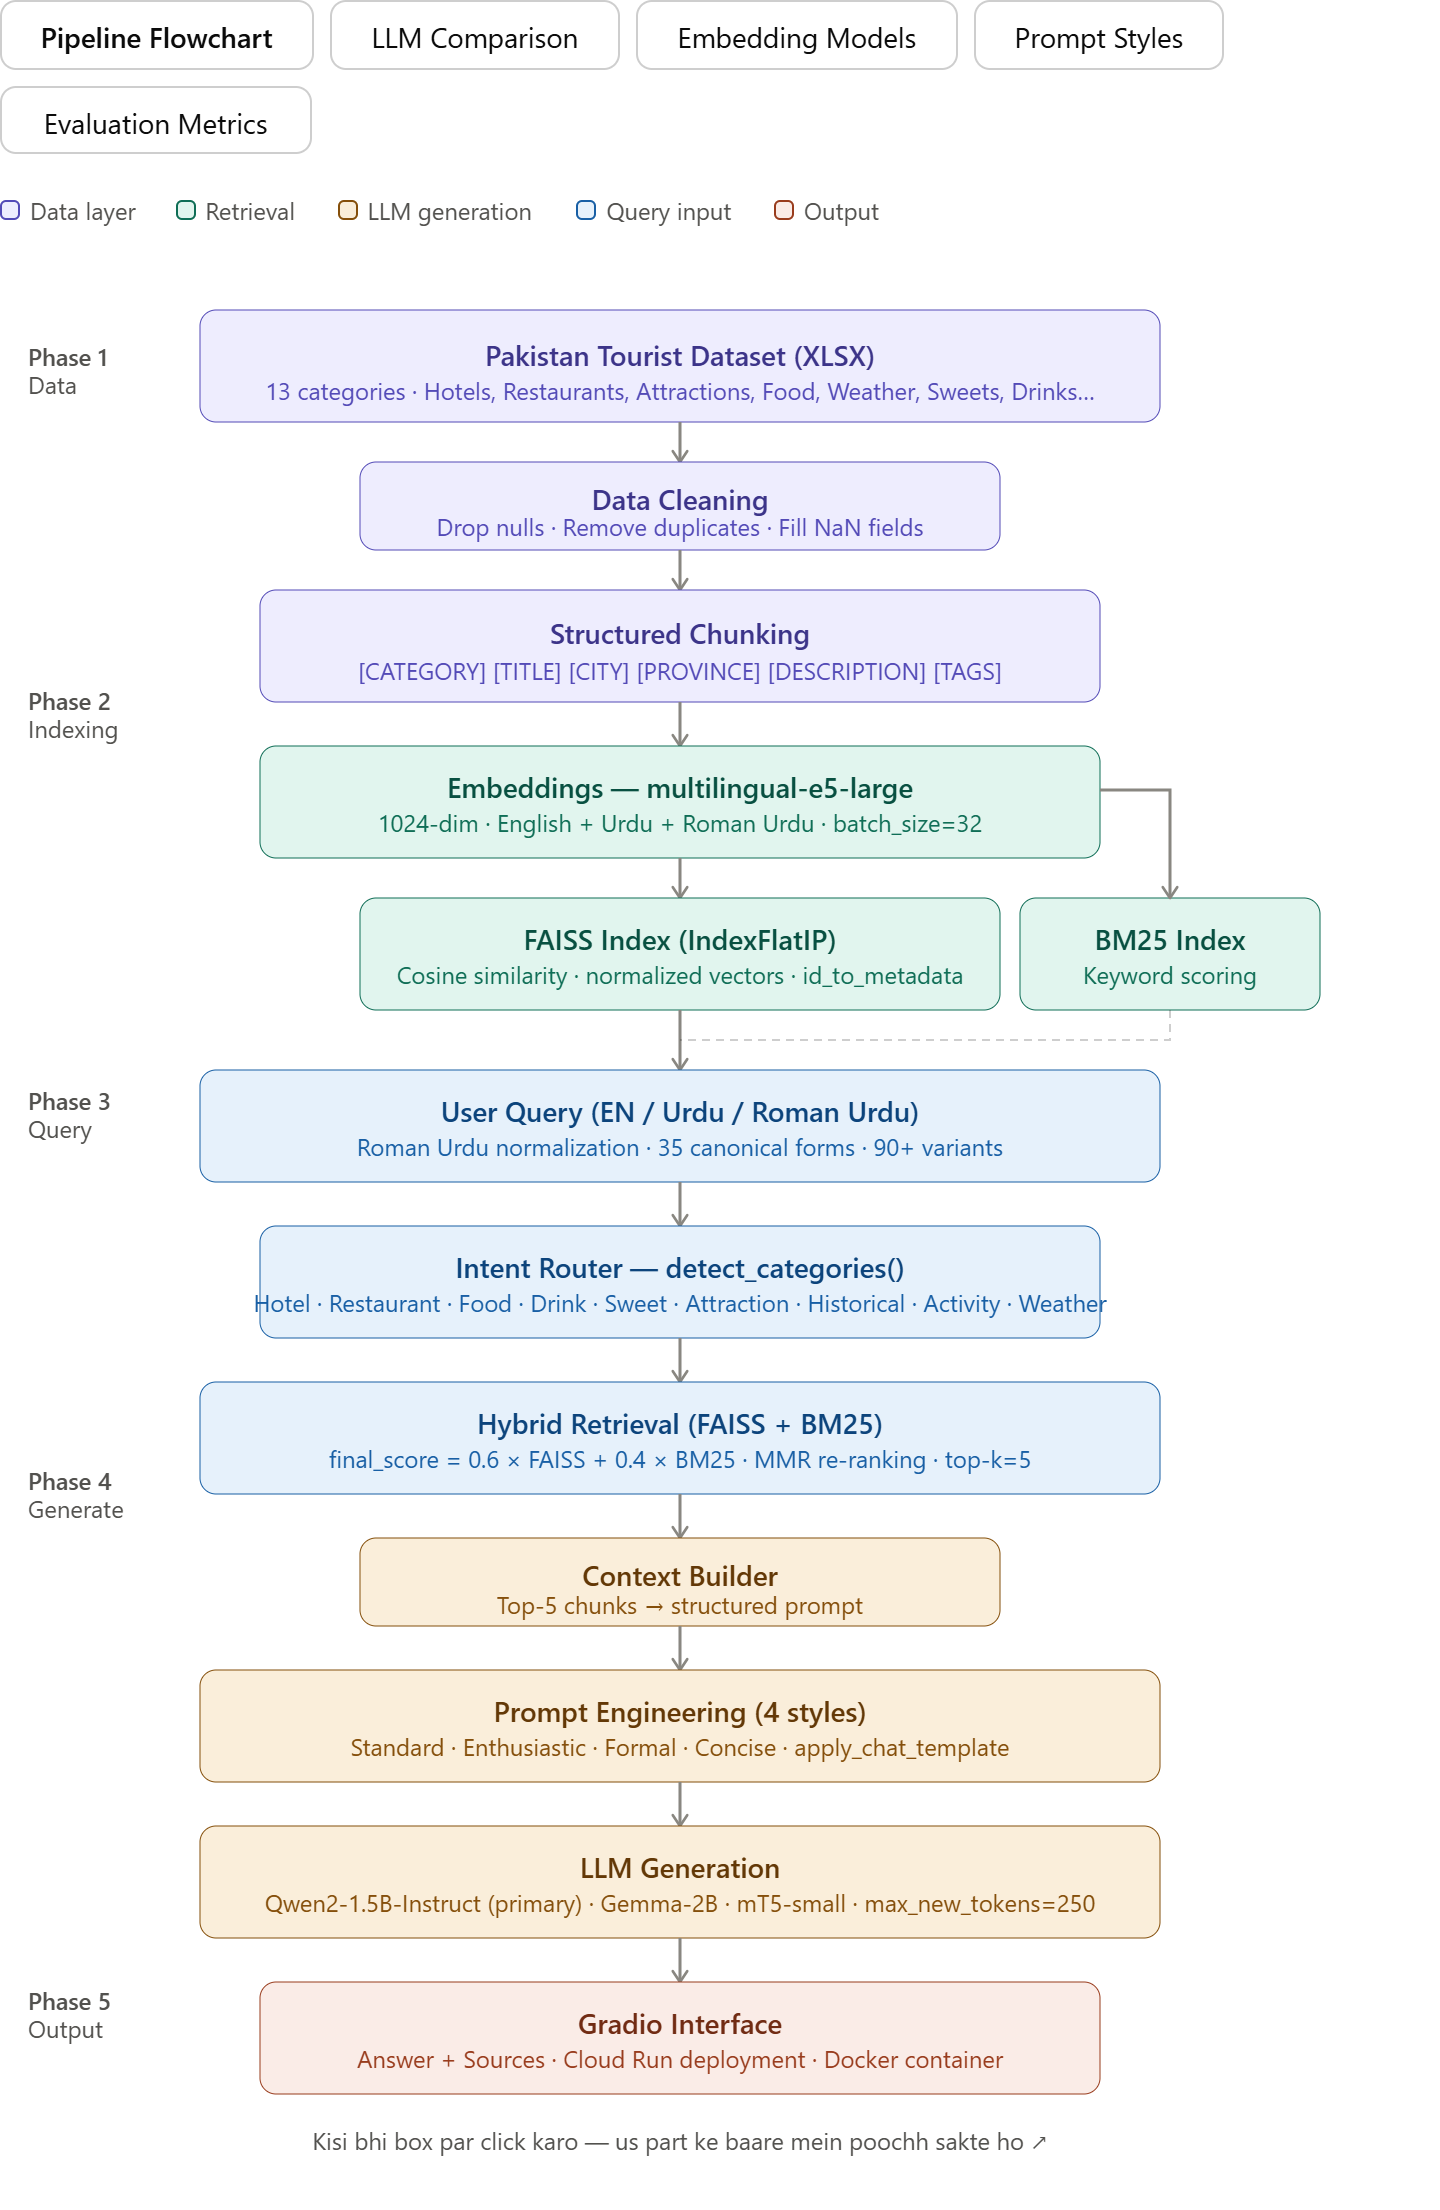

In [ ]:
import gradio as gr

# ==========================================================
# CHAT FUNCTION
# ==========================================================
def chatbot_interface(message, history):

    if history is None:
        history = []

    if message.strip() == "":
        return history, "", ""

    # Your RAG Function
    answer, sources = generate_answer(message)

    history.append({"role": "user", "content": message})
    history.append({"role": "assistant", "content": answer})

    # Sources Formatting
    if sources:

        source_text = "## 📚 Retrieved Sources\n\n"

        for source in sources:

            source_text += f"""
### 📍 {source['title']}

🏷 **Category:** {source['category']}

📍 **Location:** {source['city']}, {source['province']}

---
"""

    else:

        source_text = "## 📚 Retrieved Sources\n\nNo relevant sources found."

    return history, source_text, ""


# ==========================================================
# CUSTOM CSS
# ==========================================================

css = """
.gradio-container {
    max-width:1350px !important;
    margin:auto;
    background-color: #0A3D0A; /* Dark green for the main container background */
    color: white; /* Default text color for elements within the container */
}

body {
    background-color: #0A3D0A; /* Dark green for the entire page background */
}

footer {
    display:none;
}

h1 {
    text-align:center;
    font-size:40px;
    color:white; /* Ensure H1 text is visible on dark background */
}

h2, h3 {
    text-align:center;
    color:white; /* Ensure H2, H3 text is visible on dark background */
}

#header {
    background: #2E8B57; /* Slightly darker green for header, contrasting with body but still green */
    padding:20px;
    border-radius:15px;
    margin-bottom:20px;
}

#sources {
    background: #1A521A; /* Dark green for the sources panel, contrasting with body but still green */
    color: white; /* Ensure text in sources is white */
    border-radius:15px;
    padding:20px;
    border:1px solid #4CAF50;
    height:650px;
    overflow:auto;
}

/* Chatbot specific styling for message bubbles */
.message.user {
    background-color: #4CAF50 !important; /* Green for user messages */
    color: white !important;
    border-radius: 15px !important;
    padding: 10px !important;
}

.message.bot {
    background-color: #2E8B57 !important; /* Slightly darker green for bot messages */
    color: white !important;
    border-radius: 15px !important;
    padding: 10px !important;
}

/* Textbox for input */
.gradio-textbox textarea {
    background-color: #2E8B57 !important; /* Dark green for input textbox */
    color: white !important;
    border: 1px solid #4CAF50 !important;
}

/* Button styling for visibility */
.gr-button {
    background-color: #4CAF50 !important; /* Green buttons */
    color: white !important;
    border: none !important;
    border-radius: 10px !important;
}

/* Ensure example questions are readable */
.gradio-examples {
    color: white; /* Make example text visible */
}

/* Labels */
.gradio-label {
    color: white !important;
}
"""


# ==========================================================
# UI
# ==========================================================

with gr.Blocks(
    title="Pakistan Tourist Chatbot"
) as demo:

    gr.Markdown(
        """
<div id="header">

# 🇵🇰 Pakistan Tourist RAG Chatbot

### AI Powered Travel Assistant

🏔 Tourist Attractions • 🏨 Hotels • 🍴 Food • 🌤 Weather • 🎒 Tour Packages

</div>
"""
    )

    with gr.Row():

        with gr.Column(scale=4):

            chatbot = gr.Chatbot(
                # Removed type="messages" as it's not a valid argument for gr.Chatbot
                label="💬 Tourist Assistant",
                height=600
            )

            question = gr.Textbox(
                placeholder="Ask anything about Pakistan Tourism...",
                lines=2,
                show_label=False
            )

            with gr.Row():

                ask = gr.Button(
                    "🚀 Ask AI",
                    variant="primary"
                )

                clear = gr.Button(
                    "🗑 Clear Chat"
                )

        with gr.Column(scale=2):

            sources = gr.Markdown(
                "## 📚 Retrieved Sources",
                elem_id="sources"
            )

    gr.Markdown("## 💡 Example Questions")

    gr.Examples(

        examples=[

            "Best places to visit in Hunza?",

            "Top hotels in Murree",

            "Best food in Lahore?",

            "Weather in Skardu",

            "Tour packages for Swat",

            "Historical places in Pakistan",

            "Best lakes in Pakistan"

        ],

        inputs=question

    )

    ask.click(

        chatbot_interface,

        inputs=[question, chatbot],

        outputs=[chatbot, sources, question]

    )

    question.submit(

        chatbot_interface,

        inputs=[question, chatbot],

        outputs=[chatbot, sources, question]

    )

    clear.click(

        lambda: ([], "## 📚 Retrieved Sources", ""),

        outputs=[chatbot, sources, question]

    )

demo.queue()

demo.launch(
    css=css, # Moved css=css to demo.launch()
    theme=gr.themes.Soft(
        primary_hue="green"
    )
)

/tmp/ipykernel_1342/3314701867.py:138: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: css. Please pass these parameters to launch() instead.
  with gr.Blocks(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://bf2b7f23458f050fa5.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
